In [1]:

import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *
from sqlalchemy import create_engine
from sqlalchemy import text


In [111]:
server_sql = server_zeus
db_sql = "ODIN"
user_sql = user_zeus
pwd_sql = pwd_zeus

engine_zeus = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)

In [ ]:
config_servidores = {
    76: ["SAE","SAR","AGENDA"],
    7: ["EFECTIVA_NC"],
    64: [ "EFECTIVA_NEGOCIOS", "BCO ALFIN"],
    21: ["DINERS TC","plus","DINERS"]
}
fecha_mes_base='2026-08-01'

def obtener_info_servidor(servidor,campanas,fecha_mes_base,engine_zeus):

    print("=" * 80)
    print(f"PROCESANDO SERVIDOR: 192.168.3.{servidor}")
    print("CAMPAÑAS:")
    
    for campana in campanas:
        print(f" - {campana}")
        
    print("=" * 80)

    # ========================================================
    # 1. CONSTRUIR FILTRO DE CAMPAÑAS
    # ========================================================

    condiciones = [
        f'e.campaign_name LIKE "%{campana}%"'
        for campana in campanas
    ]

    filtro_campanas = " OR ".join(condiciones)

    print("\nFiltro generado:")
    print(filtro_campanas)


    # ========================================================
    # 2. EXTRAER DIAL LOG
    # ========================================================

    query_dial = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor}], '
    
    SELECT
        admin_log_id,
        event_date,
        user,
        event_section,
        event_type,
        record_id,
        event_code,
        event_sql,
        event_notes
    FROM asterisk.vicidial_admin_log
    WHERE event_sql LIKE '%dial_method%'
    ORDER BY event_date DESC;
    ')
    """

    df_dial = pd.read_sql(
        query_dial,
        engine_zeus
    )

    print("\nDial Log:", len(df_dial))


    # ========================================================
    # 3. EXTRAER VICIDIAL LOG
    # ========================================================

    query_vic = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor}], '

    SELECT
        a.lead_id,
        a.uniqueid,
        RTRIM(LTRIM(d.vendor_lead_code)) AS vendor_lead_code,
        e.dial_method,
        a.campaign_id AS numero_campana,
        a.user AS dni_ejecutivo,
        c.full_name AS ejecutivo,
        e.campaign_name AS nombre_campana,
        a.call_date AS fecha_hora_llamada,
        a.length_in_sec AS duracion,
        b.status_name AS call_result,
        f.list_description,
        f.list_name,
        a.phone_number AS phone_number,
        d.alt_phone AS fecha_agenda,
        d.comments AS comentarios, 
        a.status AS codigo
    FROM asterisk.vicidial_log a
    LEFT JOIN asterisk.vicidial_list d ON a.lead_id = d.lead_id
    LEFT JOIN asterisk.vicidial_campaigns e ON a.campaign_id = e.campaign_id
    LEFT JOIN asterisk.vicidial_lists f ON a.list_id = f.list_id 
    LEFT JOIN asterisk.vicidial_statuses b ON a.status = b.status
    LEFT JOIN asterisk.vicidial_users c ON a.user = c.user
    WHERE
        (
            {filtro_campanas}
        )

    AND a.call_date >= DATE_FORMAT(
        ''{fecha_mes_base}'',
        ''%Y-%m-01''
    )

    AND a.call_date <
        DATE_ADD(
            DATE_FORMAT(
                ''{fecha_mes_base}'',
                ''%Y-%m-01''
            ),
            INTERVAL 1 MONTH
        )

    ')
    """

    df_vic = pd.read_sql(
        query_vic,
        engine_zeus
    )

    print("Vicidial Log:", len(df_vic))


    # ========================================================
    # 4. PREPARAR DIAL LOG
    # ========================================================

    df_dial["call_date"] = pd.to_datetime(
        df_dial["call_date"],
        errors="coerce"
    )

    df_dial["lead_id"] = pd.to_numeric(
        df_dial["lead_id"],
        errors="coerce"
    )

    df_dial = (
        df_dial
        .dropna(
            subset=[
                "lead_id",
                "call_date"
            ]
        )
        .copy()
    )

    df_dial["lead_id"] = (
        df_dial["lead_id"]
        .astype("int64")
    )

    df_dial = (
        df_dial
        .sort_values(
            [
                "call_date",
                "lead_id"
            ]
        )
        .reset_index(drop=True)
    )


    # ========================================================
    # 5. PREPARAR VICIDIAL LOG
    # ========================================================

    df_vic["fecha_hora_llamada"] = pd.to_datetime(
        df_vic["fecha_hora_llamada"],
        errors="coerce"
    )

    df_vic["lead_id"] = pd.to_numeric(
        df_vic["lead_id"],
        errors="coerce"
    )

    df_vic = (
        df_vic
        .dropna(
            subset=[
                "lead_id",
                "fecha_hora_llamada"
            ]
        )
        .copy()
    )

    df_vic["lead_id"] = (
        df_vic["lead_id"]
        .astype("int64")
    )

    df_vic = (
        df_vic
        .sort_values(
            [
                "fecha_hora_llamada",
                "lead_id"
            ]
        )
        .reset_index(drop=True)
    )


    # ========================================================
    # 6. CRUZAR VICIDIAL LOG VS DIAL LOG
    # ========================================================

    df_final = pd.merge_asof(

        df_vic,

        df_dial[
            [
                "lead_id",
                "call_date",
                "proveedor",
                "sip_hangup_cause",
                "sip_hangup_reason",
                "extension",
                "channel",
                "context",
                "server_ip",
                "caller_code"
            ]
        ],

        left_on="fecha_hora_llamada",

        right_on="call_date",

        by="lead_id",

        direction="backward",

        tolerance=pd.Timedelta(
            seconds=90
        )
    )


    # ========================================================
    # 7. DIFERENCIA DE SEGUNDOS
    # ========================================================

    df_final["diferencia_segundos"] = (

        df_final["fecha_hora_llamada"]

        - df_final["call_date"]

    ).dt.total_seconds()


    # ========================================================
    # 8. AGREGAR SERVIDOR
    # ========================================================

    df_final["servidor"] = (
        f"192.168.3.{servidor}"
    )


    # ========================================================
    # 9. VALIDACIÓN DEL MATCH
    # ========================================================

    total = len(df_final)

    con_proveedor = (
        df_final["proveedor"]
        .notna()
        .sum()
    )

    sin_proveedor = (
        df_final["proveedor"]
        .isna()
        .sum()
    )

    porcentaje = (
        con_proveedor
        / total
        * 100
        if total > 0
        else 0
    )


    print("\n" + "-" * 80)

    print(
        f"TOTAL SERVIDOR {servidor}:",
        total
    )

    print(
        "Con proveedor:",
        con_proveedor
    )

    print(
        "Sin proveedor:",
        sin_proveedor
    )

    print(
        "% Match:",
        round(porcentaje, 2),
        "%"
    )

    print("\nProveedores:")

    print(
        df_final["proveedor"]
        .value_counts(
            dropna=False
        )
    )

    print("-" * 80)

    return df_final

In [24]:
lista_servidores = []


for servidor, campanas in config_servidores.items():

    try:

        df_temp = obtener_info_servidor(
            servidor=servidor,
            campanas=campanas,
            fecha_mes_base=fecha_mes_base,
            engine_zeus=engine_zeus
        )
        lista_servidores.append( df_temp)
    except Exception as e:

        print("\n" + "!" * 80)
        print(
            f"ERROR EN SERVIDOR {servidor}"
        )
        print(e)
        print("!" * 80)

PROCESANDO SERVIDOR: 192.168.3.76
CAMPAÑAS:
 - SAE
 - SAR
 - AGENDA

Filtro generado:
e.campaign_name LIKE "%SAE%" OR e.campaign_name LIKE "%SAR%" OR e.campaign_name LIKE "%AGENDA%"

Dial Log: 215233
Vicidial Log: 214592

--------------------------------------------------------------------------------
TOTAL SERVIDOR 76: 214592
Con proveedor: 214582
Sin proveedor: 10
% Match: 100.0 %

Proveedores:
proveedor
INTELVOX    213600
PERUCALL       982
NaN             10
Name: count, dtype: int64
--------------------------------------------------------------------------------
PROCESANDO SERVIDOR: 192.168.3.7
CAMPAÑAS:
 - EFECTIVA_NC

Filtro generado:
e.campaign_name LIKE "%EFECTIVA_NC%"

Dial Log: 16822
Vicidial Log: 16822

--------------------------------------------------------------------------------
TOTAL SERVIDOR 7: 16822
Con proveedor: 16822
Sin proveedor: 0
% Match: 100.0 %

Proveedores:
proveedor
INTELVOX    16822
Name: count, dtype: int64
-----------------------------------------------

In [25]:
df_total_agosto = pd.concat(
    lista_servidores,
    ignore_index=True
)

In [26]:
print( "TOTAL GENERAL:", len(df_total_agosto))
print()
print( df_total_agosto["servidor"].value_counts())
print()
print(df_total_agosto["proveedor"].value_counts(dropna=False))

TOTAL GENERAL: 783982

servidor
192.168.3.64    361451
192.168.3.76    214592
192.168.3.21    191117
192.168.3.7      16822
Name: count, dtype: int64

proveedor
INTELVOX    649727
PERUCALL    134152
NaN            103
Name: count, dtype: int64


In [ ]:
df_total_agosto["codigo"] = (
    df_total_agosto["codigo"]
    .astype(str)
    .str.strip()
)

mask = df_total_agosto["codigo"].str.fullmatch(r"\d+")

df_total_agosto.loc[mask, "codigo"] = (
    "AL" + df_total_agosto.loc[mask, "codigo"]
)
# 1. CHS005 → CHS002
df_total_agosto["codigo"] = (
    df_total_agosto["codigo"]
    .replace("CHS005", "CHS002")
)

# 2. Reemplazar CHS00 por AL
df_total_agosto["codigo"] = (
    df_total_agosto["codigo"]
    .str.replace(
        r"^CHS00",
        "AL",
        regex=True
    )
)
df_total_agosto["codigo"] = (
    df_total_agosto["codigo"]
    .str.replace(
        r"^CHS0",
        "AL",
        regex=True
    )
)
df_total_agosto["proveedor"] = (
    df_total_agosto["proveedor"]
    .fillna("PROVEEDOR NO IDENTIFICADO")
)

In [113]:
maquina=['AA', 'DROP', 'AB', 'NA','PDROP', 'ADC', 'AM','AL']
contato_1=['CALLBK', 'INCALL','XFER','CBHOLD']

query_vic = f"""
    SELECT DISTINCT estado,descripcion,codigo
    FROM (
        select [NIVEL 2] as estado,[NIVEL 4] as descripcion,cod as codigo 
        from ODIN.dbo.tTipologia_Diners_TC
        where cod like 'E0%'

        UNION

        select [NIVEL 2] as estado,[NIVEL 4] as descripcion,cod as codigo  
        from ODIN.dbo.tTipologia_Diners_PPD
        where cod like 'C0%'
            UNION

        select tipo as estado,descripcion,codigo  
        from ODIN.dbo.tTipologia_Efectiva
        where codigo like 'B0%'

        UNION

        select tipo as estado,descripcion,codigo  
        from ODIN.dbo.tTipologia_Cencosud_PPFF
        where codigo like 'R0%'

        UNION

        select distinct case 
        when estado='CONTACTO EFECTIVO CON TITULAR' then 'CONTACTO EFECTIVO'
        when estado='CONTACTO CON TERCERO NO RELACIONADO' then 'CONTACTO NO EFECTIVO'
        when estado='CONTACTO CON TERCERO' then 'CONTACTO NO EFECTIVO'
        when estado='DISCADOR' then 'MAQUINA'
        when estado='DISCADOR (AUTO)' then 'MAQUINA'
        when estado='NO CONTACTO' then 'NO CONTACTO'
        end as estado,descripcion,codigo
        from [192.168.2.50].[ODIN].[dbo].[tTipologia_Alfin]
        where estado is not null
    ) t
    """
df_tipi = pd.read_sql(query_vic,engine_zeus)
df_tipi=df_tipi.drop_duplicates('codigo')
df_total_agosto_01=df_total_agosto.merge(df_tipi,on='codigo',how='left')

df_total_agosto_01.loc[
    df_total_agosto_01["codigo"].isin(maquina),
    "estado"
] = "MAQUINA"

df_total_agosto_01.loc[
    df_total_agosto_01["codigo"].isin(contato_1),
    "estado"
] = "CONTACTO EFECTIVO"
df_total_agosto_01["tipo_contacto"] = np.where(
    df_total_agosto_01["estado"].isin(['MAQUINA']),
    "MAQUINA",
    "CONTACTO"
)

columnas_limpiar = [
    "dial_method",
    "proveedor",
    "tipo_contacto",
    "estado",
    "codigo",
    "nombre_campana"
]

for col in columnas_limpiar:
    df_total_agosto_01[col] = (
        df_total_agosto_01[col]
        .astype(str)
        .str.strip()
    )

In [36]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


In [115]:
df_total_agosto_01["dial_method"].value_counts(dropna=False).reset_index()


,dial_method,count
0,RATIO,779731
1,MANUAL,4251


In [38]:
df_codigos = (
    df_total_agosto_01.loc[
        df_total_agosto_01["estado"].isnull(),
        ["codigo"]
    ]
    .drop_duplicates()
)

print(df_codigos['codigo'].unique().tolist())

[]


¿En qué campañas está cada proveedor?
        ↓
¿Ambos proveedores trabajaron las mismas campañas?
        ↓
¿En qué días?
        ↓
¿Manual o predictivo?
        ↓
Recién entonces:
¿Quién obtuvo mejores resultados?

## VALORES DE DIAL_METHOD

  dial_method  cantidad  porcentaje
0       RATIO    779631    99.45808
1      MANUAL      4248     0.54192


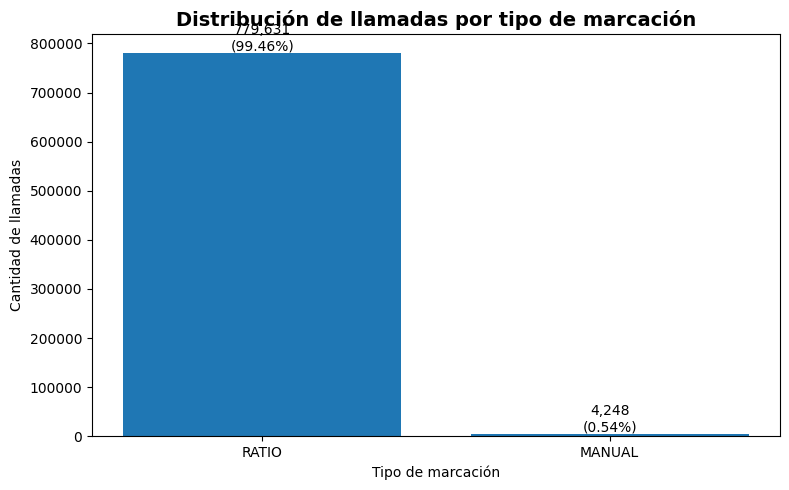

In [144]:
import matplotlib.pyplot as plt

resumen_dial = (
    df_total_agosto_01[
        df_total_agosto_01["proveedor"].isin(
            ["PERUCALL", "INTELVOX"]
        )
    ]["dial_method"]
    .value_counts(dropna=True)
    .reset_index()
)

resumen_dial.columns = [
    "dial_method",
    "cantidad"
]

# Porcentaje
resumen_dial["porcentaje"] = (
    resumen_dial["cantidad"]
    / resumen_dial["cantidad"].sum()
    * 100
)

print(resumen_dial)


# ============================================================
# GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(
    resumen_dial["dial_method"].astype(str),
    resumen_dial["cantidad"]
)

ax.set_title(
    "Distribución de llamadas por tipo de marcación",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Tipo de marcación")
ax.set_ylabel("Cantidad de llamadas")

# ============================================================
# ETIQUETAS
# ============================================================

for barra, cantidad, porcentaje in zip(
    barras,
    resumen_dial["cantidad"],
    resumen_dial["porcentaje"]
):
    
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{cantidad:,.0f}\n({porcentaje:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

,dial_method,proveedor,cantidad,porcentaje
0,MANUAL,INTELVOX,1173,27.593507
1,MANUAL,PERUCALL,3075,72.335921
2,MANUAL,PROVEEDOR NO IDENTIFICADO,3,0.070572
3,RATIO,INTELVOX,648554,83.176634
4,RATIO,PERUCALL,131077,16.810541
5,RATIO,PROVEEDOR NO IDENTIFICADO,100,0.012825


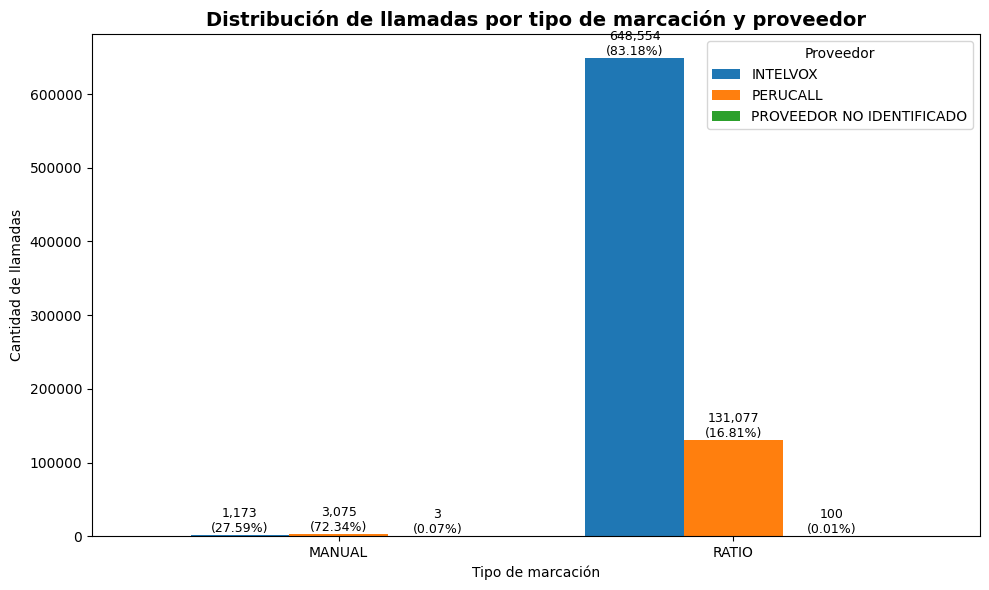

In [145]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FILTRAR PROVEEDORES
# ============================================================

df_grafico = df_total_agosto_01.copy()

# ============================================================
# RESUMEN DIAL_METHOD + PROVEEDOR
# ============================================================

resumen_dial = (
    df_grafico
    .groupby(
        ["dial_method", "proveedor"],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)

# ============================================================
# PORCENTAJE DENTRO DE CADA DIAL_METHOD
# ============================================================

resumen_dial["porcentaje"] = (
    resumen_dial["cantidad"]
    / resumen_dial.groupby("dial_method")["cantidad"].transform("sum")
    * 100
)

display(resumen_dial)

# ============================================================
# PIVOT PARA GRÁFICO
# ============================================================

pivot = resumen_dial.pivot(
    index="dial_method",
    columns="proveedor",
    values="cantidad"
).fillna(0)

# ============================================================
# GRÁFICO
# ============================================================

ax = pivot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

ax.set_title(
    "Distribución de llamadas por tipo de marcación y proveedor",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Tipo de marcación")
ax.set_ylabel("Cantidad de llamadas")

ax.tick_params(
    axis="x",
    rotation=0
)

# ============================================================
# ETIQUETAS: CANTIDAD + PORCENTAJE
# ============================================================

for container, proveedor in zip(
    ax.containers,
    pivot.columns
):

    for barra, dial_method in zip(
        container,
        pivot.index
    ):

        cantidad = barra.get_height()

        if cantidad > 0:

            total_dial = pivot.loc[dial_method].sum()

            porcentaje = (
                cantidad / total_dial * 100
            )

            ax.text(
                barra.get_x() + barra.get_width() / 2,
                cantidad,
                f"{cantidad:,.0f}\n({porcentaje:.2f}%)",
                ha="center",
                va="bottom",
                fontsize=9
            )

ax.legend(
    title="Proveedor"
)

plt.tight_layout()
plt.show()

In [146]:
# ============================================================
# 2. DIAL_METHOD POR CAMPAÑA
# ============================================================

df_total_agosto_02 = df_total_agosto_01[
    df_total_agosto_01["proveedor"].isin(
        ["PERUCALL", "INTELVOX"]
    )
].copy()

campanas_dial = (
    df_total_agosto_02[
        [
            "servidor",
            "numero_campana",
            "nombre_campana",
            "dial_method"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "servidor",
            "nombre_campana"
        ]
    )
)

print(
    campanas_dial.to_string(index=False)
)

    servidor numero_campana            nombre_campana dial_method
192.168.3.21            409            2026-07 DINERS       RATIO
192.168.3.21            410       2026-07 DINERS PLUS       RATIO
192.168.3.21            134         2026-07 DINERS TC       RATIO
192.168.3.21            412            2026-08 DINERS       RATIO
192.168.3.21            413       2026-08 DINERS PLUS      MANUAL
192.168.3.21            136         2026-08 DINERS TC       RATIO
192.168.3.64            401         2026-08 BCO ALFIN       RATIO
192.168.3.64            403         2026-08 BCO ALFIN       RATIO
192.168.3.64            144 2026-08 EFECTIVA_NEGOCIOS       RATIO
 192.168.3.7            127       2026-07 EFECTIVA_NC       RATIO
 192.168.3.7            400           BOT_EFECTIVA_NC       RATIO
192.168.3.76             55               2026-08 SAE       RATIO
192.168.3.76             56               2026-08 SAR       RATIO
192.168.3.76             16                    AGENDA      MANUAL


## Ver proveedor por campaña

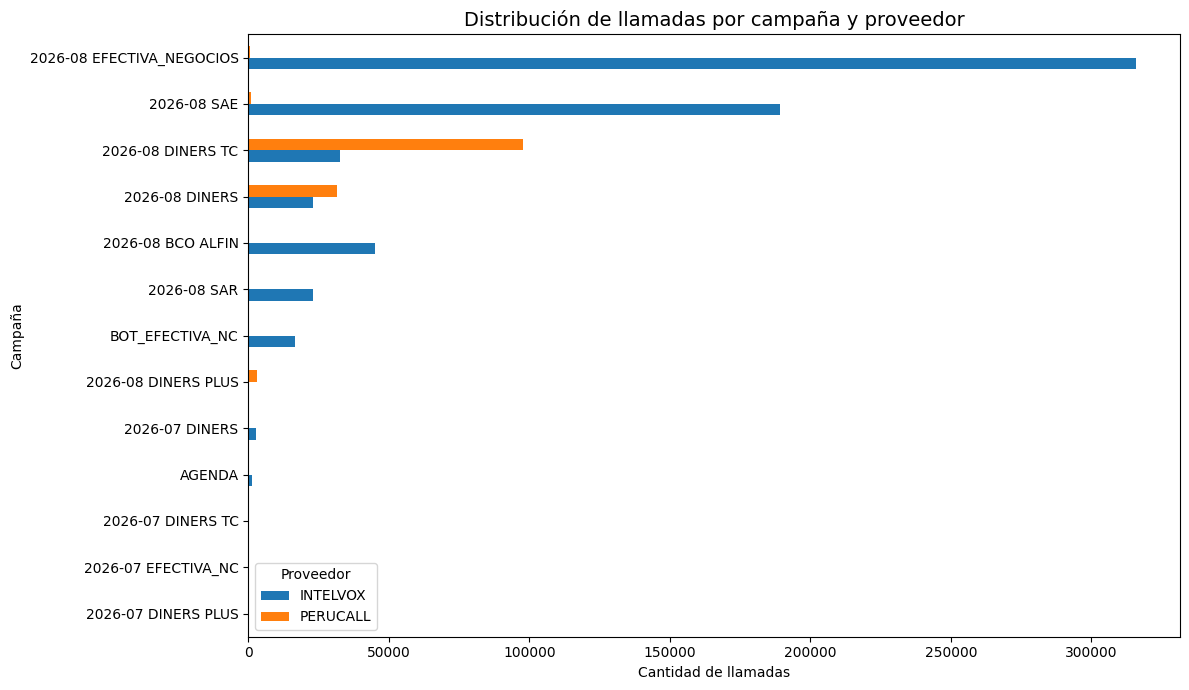

In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# VOLUMEN POR CAMPAÑA Y PROVEEDOR
# ============================================================


df_total_agosto_02 = df_total_agosto_01[
    df_total_agosto_01["proveedor"].isin(
        ["PERUCALL", "INTELVOX"]
    )
].copy()

df_grafico_campana = (
    df_total_agosto_01[
        df_total_agosto_01["proveedor"].isin(
            ["PERUCALL", "INTELVOX"]
        )
    ]
    .groupby(
        ["nombre_campana", "proveedor"]
    )
    .size()
    .unstack(fill_value=0)
)

# Ordenar por volumen total
df_grafico_campana["TOTAL"] = (
    df_grafico_campana.sum(axis=1)
)

df_grafico_campana = (
    df_grafico_campana
    .sort_values("TOTAL", ascending=True)
    .drop(columns="TOTAL")
)

# ============================================================
# GRÁFICO
# ============================================================

ax = df_grafico_campana.plot(
    kind="barh",
    figsize=(12, 7)
)

ax.set_title(
    "Distribución de llamadas por campaña y proveedor",
    fontsize=14
)

ax.set_xlabel("Cantidad de llamadas")
ax.set_ylabel("Campaña")

ax.legend(
    title="Proveedor"
)

plt.tight_layout()
plt.show()

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. PREPARAR BASE
# ============================================================

df_cambios = df_total_agosto_01.copy()

df_cambios["fecha_hora_llamada"] = pd.to_datetime(
    df_cambios["fecha_hora_llamada"],
    errors="coerce"
)

df_cambios["fecha"] = df_cambios["fecha_hora_llamada"].dt.date
df_cambios["hora"] = df_cambios["fecha_hora_llamada"].dt.hour


# ============================================================
# 2. FILTRAR CAMPAÑA Y FECHA
# ============================================================

campana = "2026-08 DINERS TC"
fecha_analisis = pd.to_datetime("2026-08-05").date()

df_dia = df_cambios[
    (df_cambios["nombre_campana"] == campana)
    &
    (df_cambios["fecha"] == fecha_analisis)
    &
    (df_cambios["proveedor"].isin(["PERUCALL", "INTELVOX"]))
].copy()


# ============================================================
# 3. CONTAR LLAMADAS POR HORA Y PROVEEDOR
# ============================================================

tabla_hora = (
    df_dia
    .groupby(["hora", "proveedor"])
    .size()
    .unstack(fill_value=0)
)

# Asegurar que existan ambas columnas
for proveedor in ["PERUCALL", "INTELVOX"]:
    if proveedor not in tabla_hora.columns:
        tabla_hora[proveedor] = 0

tabla_hora = tabla_hora[
    ["PERUCALL", "INTELVOX"]
]

display(tabla_hora)

proveedor,PERUCALL,INTELVOX
hora,,
8,7,0
9,2457,16
10,1420,362
11,0,1458
12,0,3070
13,0,3910
14,0,297
15,0,3394
16,0,3443


In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. PREPARAR DATOS
# ============================================================

df_diners = df_total_agosto_01.copy()

df_diners["fecha_hora_llamada"] = pd.to_datetime(
    df_diners["fecha_hora_llamada"],
    errors="coerce"
)

df_diners["fecha"] = (
    df_diners["fecha_hora_llamada"]
    .dt.date
)

# ============================================================
# 2. FILTRAR DINERS TC
# ============================================================

df_diners = df_diners[
    (df_diners["nombre_campana"] == "2026-08 DINERS TC")
    &
    (df_diners["proveedor"].isin(["PERUCALL", "INTELVOX"]))
].copy()

# ============================================================
# 3. RESUMEN POR DÍA Y PROVEEDOR
# ============================================================

tabla_dia = (
    df_diners
    .groupby(
        ["fecha", "proveedor"]
    )
    .size()
    .unstack(fill_value=0)
)

# asegurar columnas
for proveedor in ["PERUCALL", "INTELVOX"]:
    if proveedor not in tabla_dia.columns:
        tabla_dia[proveedor] = 0

tabla_dia = tabla_dia[
    ["PERUCALL", "INTELVOX"]
]

display(tabla_dia)

proveedor,PERUCALL,INTELVOX
fecha,,
2026-08-01,9991,64
2026-08-03,13048,425
2026-08-04,18260,156
2026-08-05,3884,18877
2026-08-06,0,4308
2026-08-07,17142,1617
2026-08-08,9715,90
2026-08-10,15502,173
2026-08-11,10067,6680


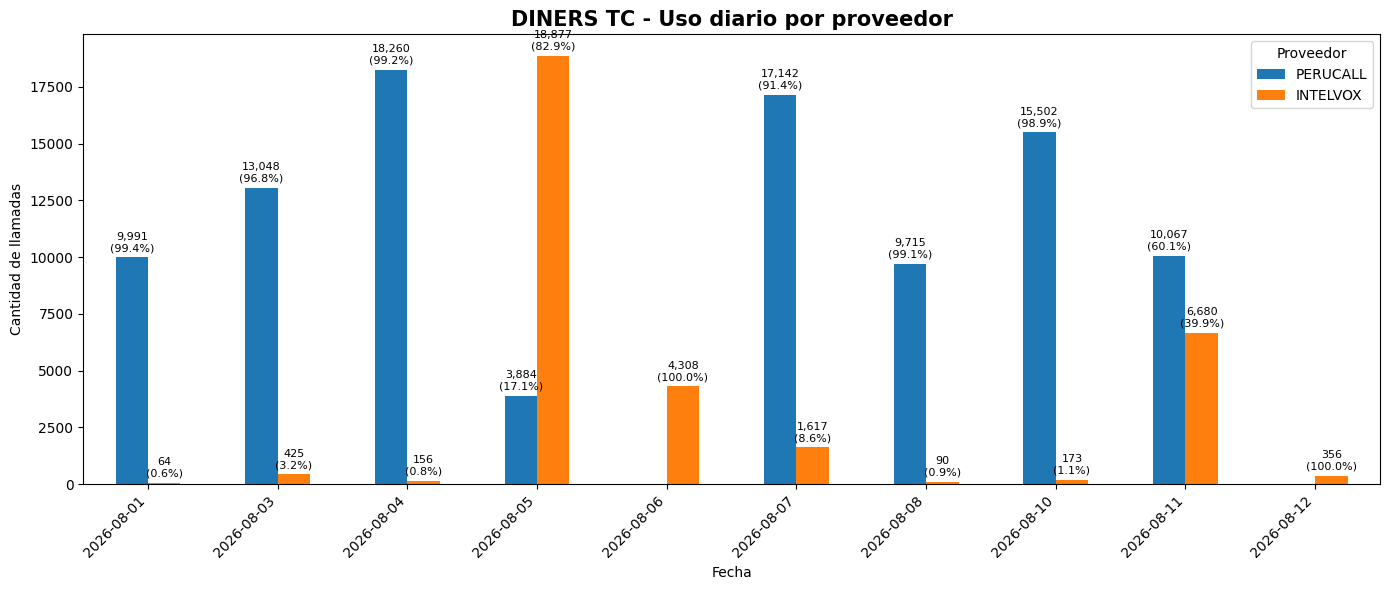

In [77]:
# ============================================================
# 4. GRÁFICO DIARIO + CANTIDAD + PORCENTAJE
# ============================================================

import matplotlib.pyplot as plt

# Total de llamadas de cada día
total_dia = tabla_dia.sum(axis=1)

# Porcentaje de cada proveedor dentro del día
tabla_pct = (
    tabla_dia
    .div(total_dia, axis=0)
    .mul(100)
)


# ============================================================
# GRÁFICO
# ============================================================

ax = tabla_dia.plot(
    kind="bar",
    figsize=(14, 6)
)

ax.set_title(
    "DINERS TC - Uso diario por proveedor",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de llamadas")

ax.legend(
    title="Proveedor"
)

plt.xticks(
    rotation=45,
    ha="right"
)


# ============================================================
# ETIQUETAS: CANTIDAD + PORCENTAJE
# ============================================================

for container, proveedor in zip(
    ax.containers,
    tabla_dia.columns
):

    etiquetas = []

    for fecha, cantidad in zip(
        tabla_dia.index,
        tabla_dia[proveedor]
    ):

        porcentaje = tabla_pct.loc[
            fecha,
            proveedor
        ]

        # No mostrar etiqueta cuando sea 0
        if cantidad > 0:

            etiquetas.append(
                f"{cantidad:,.0f}\n({porcentaje:.1f}%)"
            )

        else:

            etiquetas.append("")

    ax.bar_label(
        container,
        labels=etiquetas,
        padding=3,
        fontsize=8
    )


plt.tight_layout()
plt.show()

In [78]:
# ============================================================
# 5. PARTICIPACIÓN % POR DÍA
# ============================================================

tabla_pct = (
    tabla_dia
    .div(
        tabla_dia.sum(axis=1),
        axis=0
    )
    * 100
)

tabla_pct = tabla_pct.round(2)

display(tabla_pct)

proveedor,PERUCALL,INTELVOX
fecha,,
2026-08-01,99.36,0.64
2026-08-03,96.85,3.15
2026-08-04,99.15,0.85
2026-08-05,17.06,82.94
2026-08-06,0.00,100.00
2026-08-07,91.38,8.62
2026-08-08,99.08,0.92
2026-08-10,98.90,1.10
2026-08-11,60.11,39.89


In [140]:
# ============================================================
# CALIDAD SIP POR PROVEEDOR
# ============================================================

df_sip = df_total_agosto_01[
    df_total_agosto_01["proveedor"].isin(
        ["PERUCALL", "INTELVOX"]
    )
].copy()

# Normalizar código SIP
df_sip["sip_hangup_cause"] = pd.to_numeric(
    df_sip["sip_hangup_cause"],
    errors="coerce"
)

# ============================================================
# CANTIDAD POR PROVEEDOR Y SIP
# ============================================================

resumen_sip = (
    df_sip
    .groupby(
        [
            "proveedor",
            "sip_hangup_cause",
            "sip_hangup_reason"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)

# ============================================================
# TOTAL POR PROVEEDOR
# ============================================================

resumen_sip["total_proveedor"] = (
    resumen_sip
    .groupby("proveedor")["cantidad"]
    .transform("sum")
)

# ============================================================
# PORCENTAJE
# ============================================================

resumen_sip["porcentaje"] = (
    resumen_sip["cantidad"]
    / resumen_sip["total_proveedor"]
    * 100
).round(2)

resumen_sip = resumen_sip.sort_values(
    ["proveedor", "cantidad"],
    ascending=[True, False]
)

display(resumen_sip)

,proveedor,sip_hangup_cause,sip_hangup_reason,cantidad,total_proveedor,porcentaje
5,INTELVOX,200.0,OK),484096,649727,74.51
9,INTELVOX,480.0,Temporarily unavailable),113913,649727,17.53
16,INTELVOX,503.0,Service Unavailable),15301,649727,2.35
11,INTELVOX,486.0,Busy here),9741,649727,1.50
6,INTELVOX,404.0,Not Found),9692,649727,1.49
4,INTELVOX,183.0,Session Progress),7569,649727,1.16
7,INTELVOX,408.0,Request Timeout),3488,649727,0.54
0,INTELVOX,0.0,,3096,649727,0.48
3,INTELVOX,181.0,Call is being forwarded),1718,649727,0.26
1,INTELVOX,100.0,Trying),305,649727,0.05


In [142]:
# df_total_agosto_01[
#     df_total_agosto_01["proveedor"].isna()
# ]["dial_method"].value_counts(dropna=False)

ruta_archivo = os.path.join(ruta_csv, 'ver_2.xlsx')

resumen_sip.to_excel(ruta_archivo, index=False)
# validacion["cantidad"].isna().sum()

# df_exportar = df_grafico_campana.reset_index()
# df_exportar.to_excel(ruta_archivo, index=False)


In [143]:
df_total_agosto_01.shape

(783982, 31)

In [80]:
tabla_sip = (
    resumen_sip
    .pivot_table(
        index=[
            "sip_hangup_cause",
            "sip_hangup_reason"
        ],
        columns="proveedor",
        values="porcentaje",
        fill_value=0
    )
    .reset_index()
)

display(tabla_sip)

proveedor,sip_hangup_cause,sip_hangup_reason,INTELVOX,PERUCALL
0,0.0,,0.48,0.01
1,100.0,Trying),0.05,0.07
2,180.0,Ringing),0.02,0.01
3,181.0,Call is being forwarded),0.26,1.97
4,183.0,Session Progress),1.16,6.38
5,200.0,OK),74.51,82.78
6,403.0,Forbidden),0.00,0.06
7,404.0,Not Found),1.49,0.94
8,408.0,Request Timeout),0.54,0.03
9,410.0,Gone),0.02,0.01


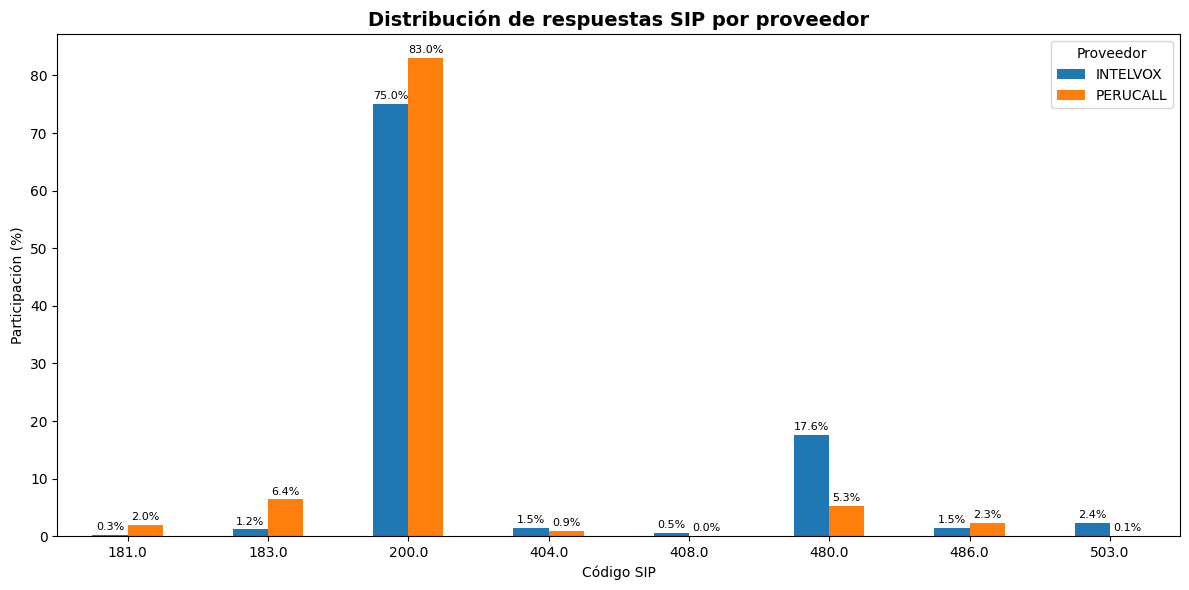

In [81]:
# ============================================================
# PRINCIPALES SIP
# ============================================================

top_sip = (
    df_sip["sip_hangup_cause"]
    .value_counts()
    .head(8)
    .index
)

df_sip_grafico = (
    df_sip[
        df_sip["sip_hangup_cause"].isin(top_sip)
    ]
    .groupby(
        ["proveedor", "sip_hangup_cause"]
    )
    .size()
    .reset_index(name="cantidad")
)

df_sip_grafico["porcentaje"] = (
    df_sip_grafico["cantidad"]
    /
    df_sip_grafico
    .groupby("proveedor")["cantidad"]
    .transform("sum")
    * 100
)

tabla_sip_grafico = (
    df_sip_grafico
    .pivot(
        index="sip_hangup_cause",
        columns="proveedor",
        values="porcentaje"
    )
    .fillna(0)
)

ax = tabla_sip_grafico.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title(
    "Distribución de respuestas SIP por proveedor",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Código SIP")
ax.set_ylabel("Participación (%)")

ax.legend(title="Proveedor")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=2,
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [82]:
# SIP	Significado
# 200	OK
# 480	Temporarily unavailable
# 486	Busy
# 503	Service unavailable
# 404	Not found


In [88]:
df_total_agosto_01.head(2)

,lead_id,uniqueid,vendor_lead_code,dial_method,numero_campana,dni_ejecutivo,ejecutivo,nombre_campana,fecha_hora_llamada,duracion,call_result,list_description,list_name,phone_number,fecha_agenda,comentarios,codigo,call_date,proveedor,sip_hangup_cause,sip_hangup_reason,extension,channel,context,server_ip,caller_code,diferencia_segundos,servidor,estado,descripcion,tipo_contacto
0,6884036,1785592801.006884036,40524635,MANUAL,16,PFC005,Sandy Margot Luyo Quiroz,AGENDA,2026-08-01 09:00:01,0.0,None,agendas,agendas,959194586,None,CONSENTIMIENTO: Y FLG_PAGO_DIFERIDO:Sin Pago Diferido ELECCION AE: LINEA DISP AE: 0PCT_ant: 0 TEA_ant: 0.0,R018,2026-08-01 08:59:28,INTELVOX,183.0,Session Progress),899959194586,Local/8600056@default,default,192.168.3.76,M8010859280006884036,33.0,192.168.3.76,NO CONTACTO,NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO),CONTACTO
1,6884224,1785593084.006884224,10673359,MANUAL,16,PFC005,Sandy Margot Luyo Quiroz,AGENDA,2026-08-01 09:04:44,0.0,None,agendas,agendas,998494144,None,CONSENTIMIENTO: Y FLG_PAGO_DIFERIDO:Con Pago Diferido ELECCION AE: LINEA DISP AE: 0PCT_ant: 0 TEA_ant: 0.0,R018,2026-08-01 09:04:40,INTELVOX,183.0,Session Progress),899998494144,Local/8600056@default,default,192.168.3.76,M8010904400006884224,4.0,192.168.3.76,NO CONTACTO,NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO),CONTACTO


In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. LIMPIAR CAMPOS
# ============================================================

columnas_limpiar = [
    "proveedor",
    "nombre_campana",
    "dial_method",
    "tipo_contacto"
]

df_total_agosto_01[columnas_limpiar] = (
    df_total_agosto_01[columnas_limpiar]
    .apply(lambda x: x.astype("string").str.strip())
)


# ============================================================
# 2. FILTRAR PROVEEDORES
# ============================================================

df_contacto = df_total_agosto_01[
    df_total_agosto_01["proveedor"].isin(
        ["PERUCALL", "INTELVOX"]
    )
].copy()


# ============================================================
# 3. RESUMEN
#    CAMPAÑA + DIAL METHOD + PROVEEDOR + CONTACTO
# ============================================================

resumen = (
    df_contacto
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor",
            "tipo_contacto"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)


# ============================================================
# 4. PORCENTAJE
#    EL % SE CALCULA DENTRO DE:
#    CAMPAÑA + DIAL_METHOD + PROVEEDOR
# ============================================================

resumen["total"] = (
    resumen
    .groupby(
        [
            "nombre_campana",
            "dial_method",
            "proveedor"
        ]
    )["cantidad"]
    .transform("sum")
)

resumen["porcentaje"] = (
    resumen["cantidad"]
    / resumen["total"]
    * 100
).round(2)


display(resumen)

,nombre_campana,dial_method,proveedor,tipo_contacto,cantidad,total,porcentaje
0,2026-07 DINERS,RATIO,INTELVOX,CONTACTO,207,2571,8.05
1,2026-07 DINERS,RATIO,INTELVOX,MAQUINA,2364,2571,91.95
2,2026-07 DINERS,RATIO,PERUCALL,CONTACTO,109,113,96.46
3,2026-07 DINERS,RATIO,PERUCALL,MAQUINA,4,113,3.54
4,2026-07 DINERS PLUS,RATIO,INTELVOX,CONTACTO,1,9,11.11
5,2026-07 DINERS PLUS,RATIO,INTELVOX,MAQUINA,8,9,88.89
6,2026-07 DINERS PLUS,RATIO,PERUCALL,CONTACTO,18,18,100.00
7,2026-07 DINERS TC,RATIO,PERUCALL,CONTACTO,13,135,9.63
8,2026-07 DINERS TC,RATIO,PERUCALL,MAQUINA,122,135,90.37
9,2026-07 EFECTIVA_NC,RATIO,INTELVOX,CONTACTO,19,84,22.62


In [91]:

ruta_archivo = os.path.join(ruta_csv, 'ver.xlsx')

resumen.to_excel(ruta_archivo, index=False)

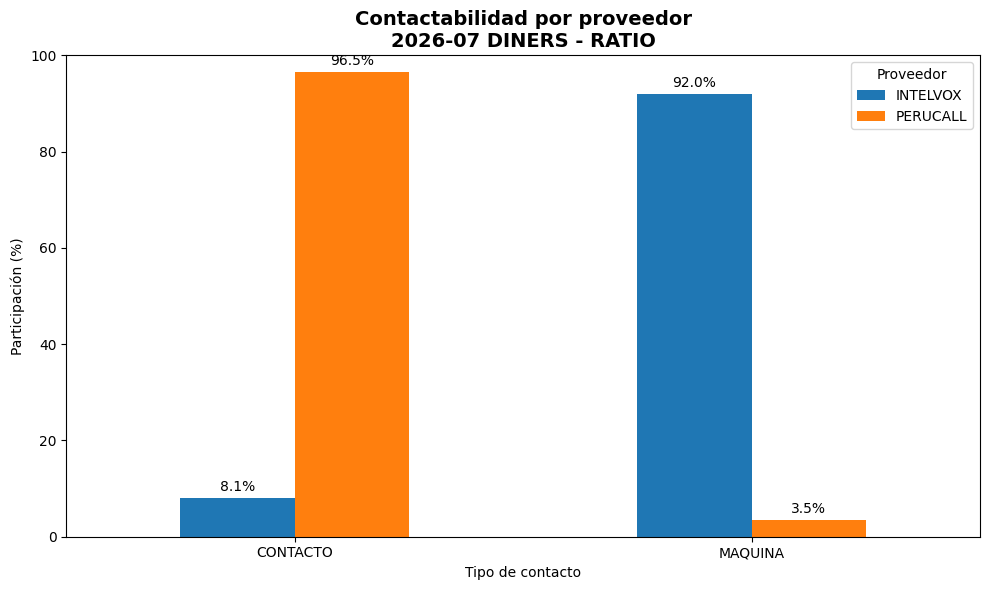

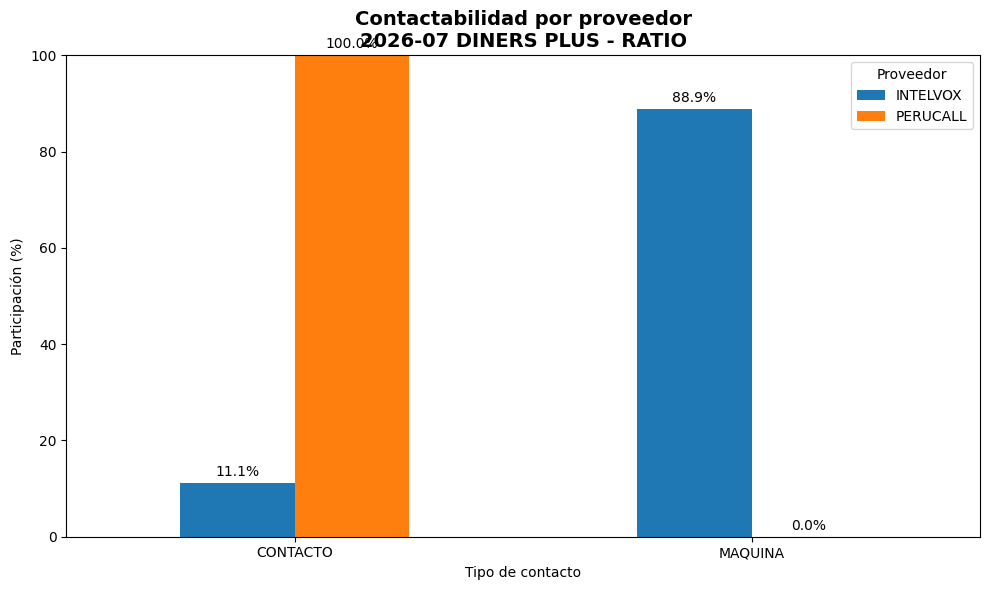

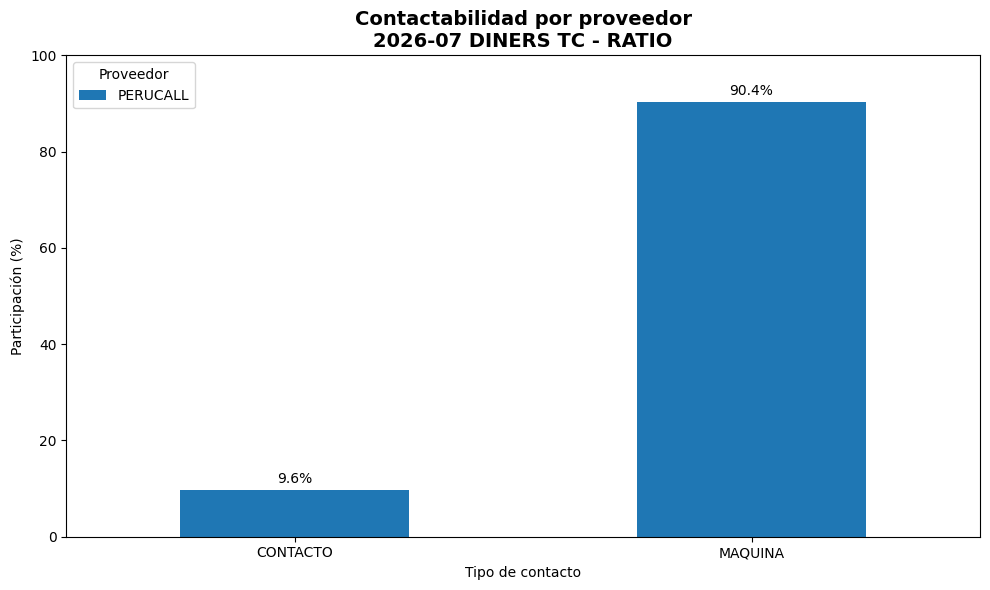

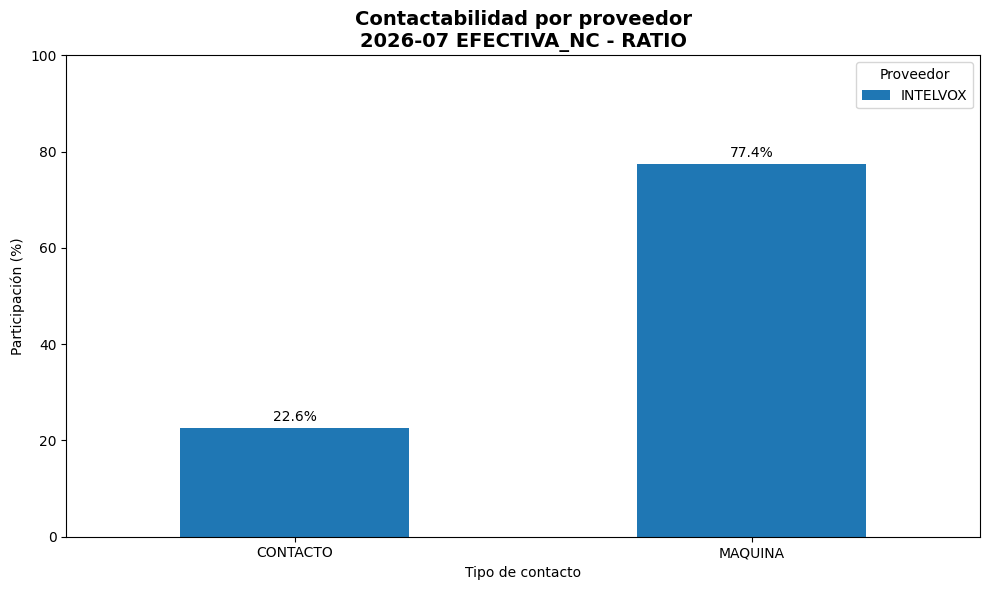

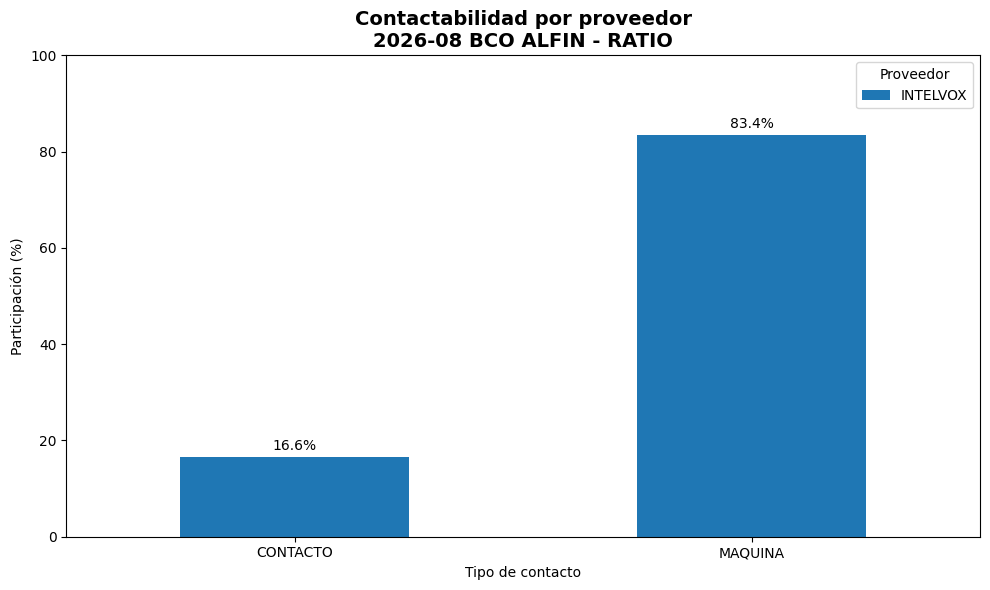

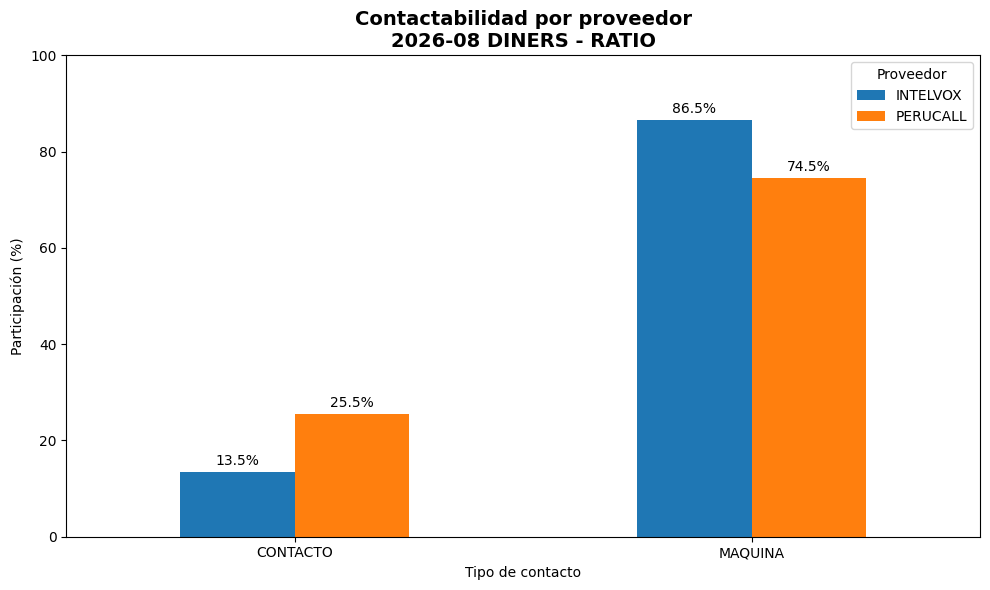

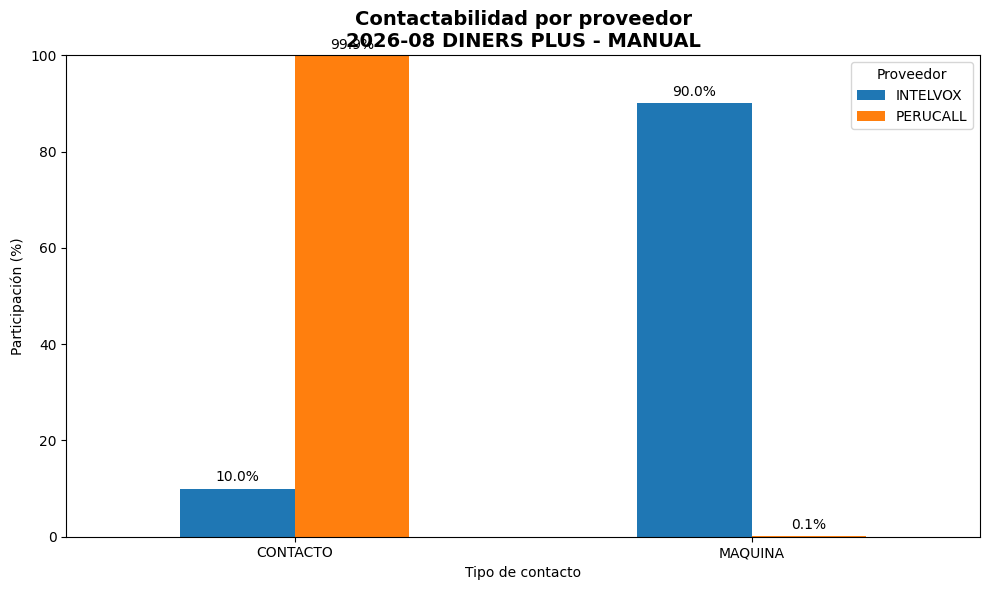

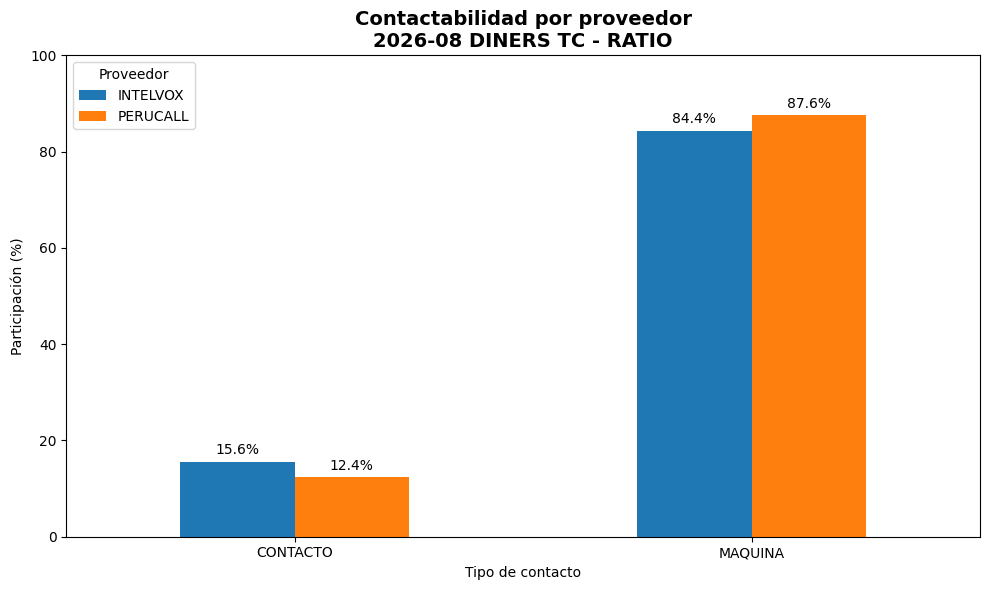

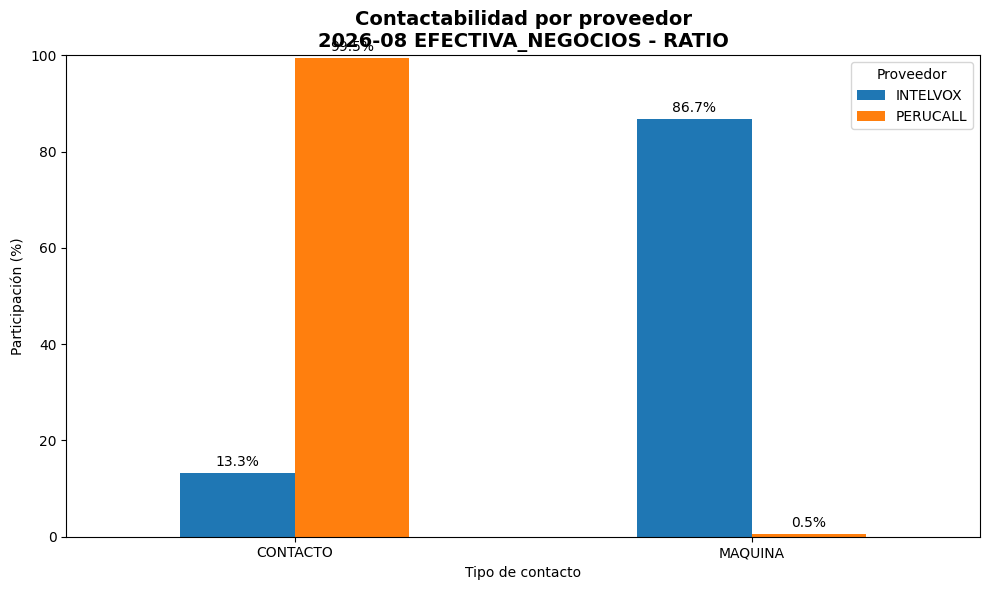

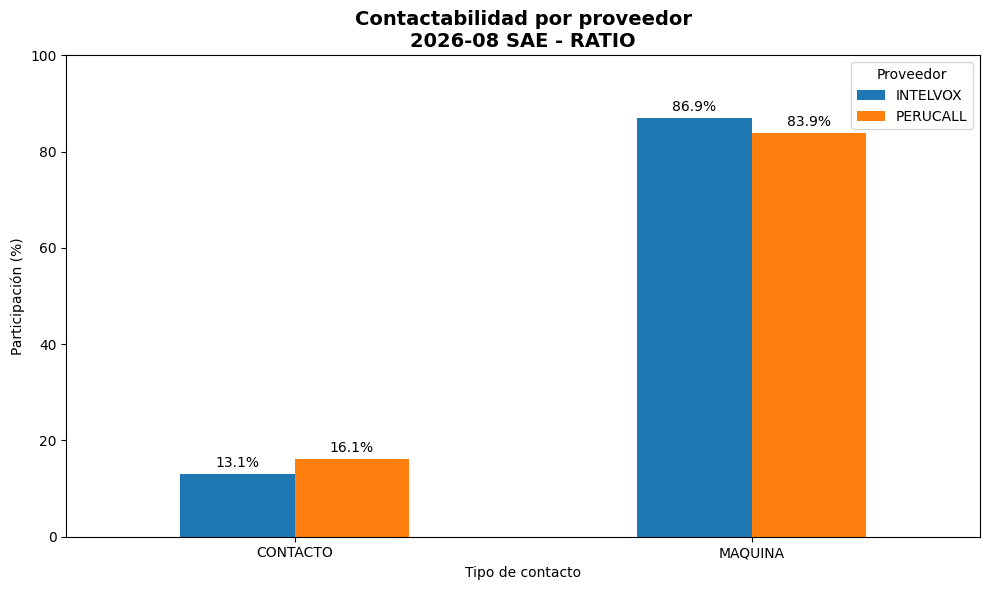

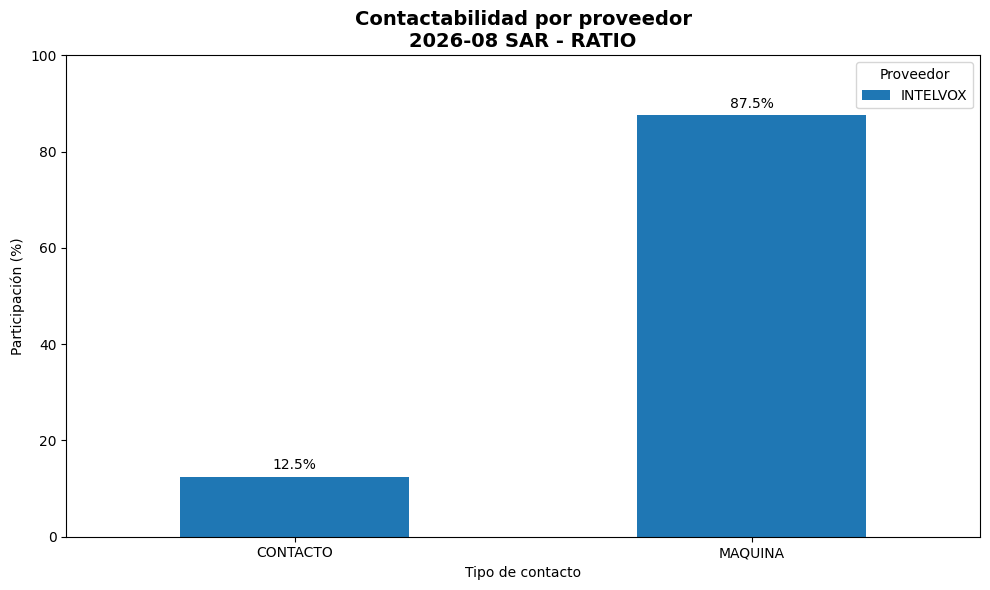

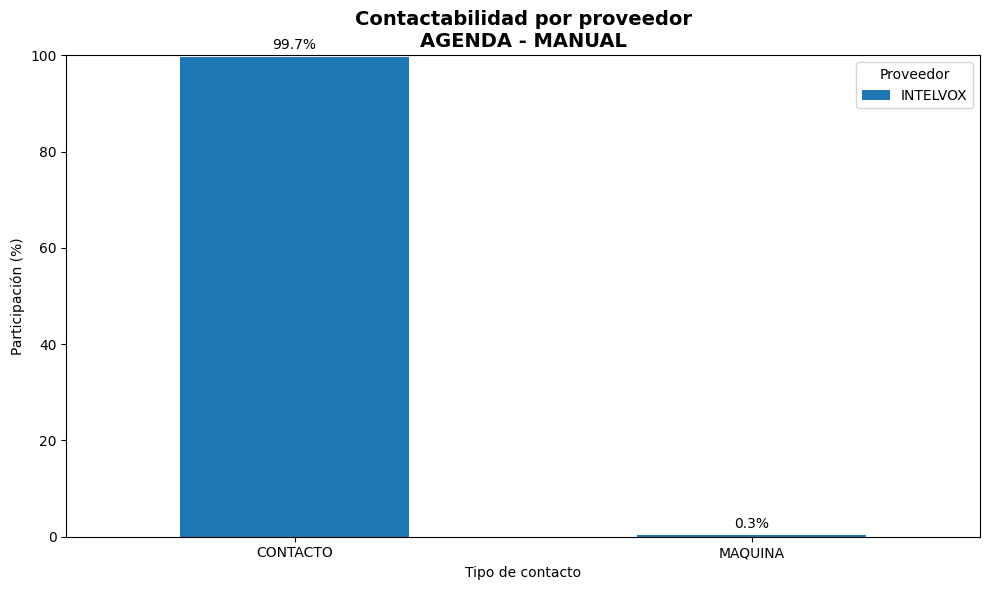

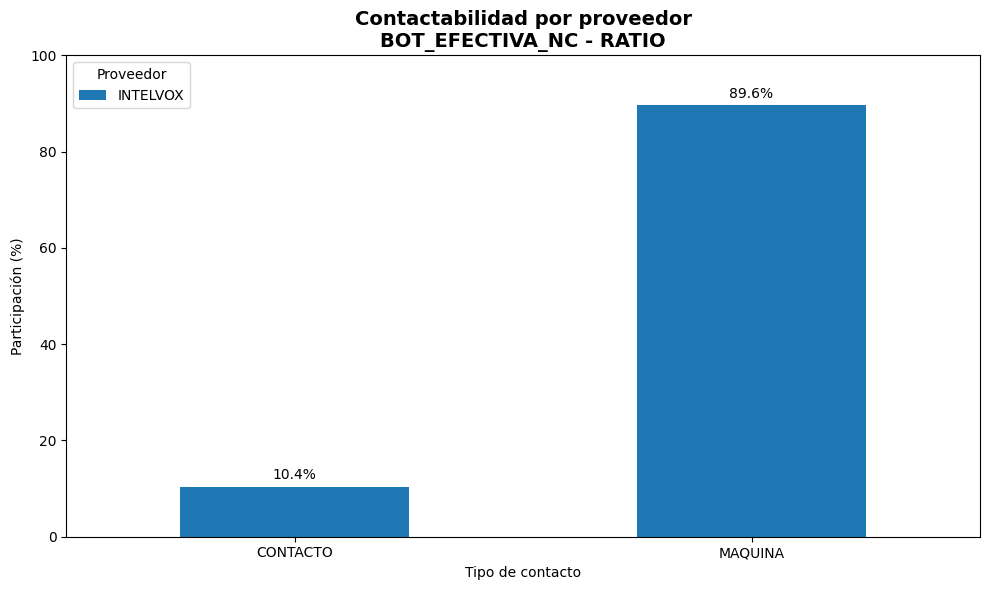

In [90]:
# ============================================================
# 5. GRÁFICO POR CAMPAÑA + DIAL_METHOD
# ============================================================

combinaciones = (
    resumen[
        ["nombre_campana", "dial_method"]
    ]
    .dropna()
    .drop_duplicates()
    .sort_values(
        ["nombre_campana", "dial_method"]
    )
)


for _, fila in combinaciones.iterrows():

    campana = fila["nombre_campana"]
    metodo = fila["dial_method"]

    # --------------------------------------------------------
    # FILTRAR CAMPAÑA + MÉTODO
    # --------------------------------------------------------

    df_grafico = resumen[
        (resumen["nombre_campana"] == campana) &
        (resumen["dial_method"] == metodo)
    ].copy()


    # --------------------------------------------------------
    # PIVOT
    # --------------------------------------------------------

    pivot = df_grafico.pivot_table(
        index="tipo_contacto",
        columns="proveedor",
        values="porcentaje",
        aggfunc="sum",
        fill_value=0
    )


    # Orden CONTACTO / MAQUINA
    orden = ["CONTACTO", "MAQUINA"]

    pivot = pivot.reindex(
        [x for x in orden if x in pivot.index]
    )


    # --------------------------------------------------------
    # GRÁFICO
    # --------------------------------------------------------

    ax = pivot.plot(
        kind="bar",
        figsize=(10, 6)
    )

    ax.set_title(
        f"Contactabilidad por proveedor\n"
        f"{campana} - {metodo}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Tipo de contacto")
    ax.set_ylabel("Participación (%)")

    ax.set_ylim(0, 100)

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=0
    )


    # --------------------------------------------------------
    # ETIQUETAS %
    # --------------------------------------------------------

    for container in ax.containers:

        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3
        )


    ax.legend(
        title="Proveedor"
    )

    plt.tight_layout()
    plt.show()

In [40]:
# ============================================================
# PROVEEDORES UTILIZADOS POR CAMPAÑA
# ============================================================

resumen_campana_proveedor = (
    df_total_agosto[
        df_total_agosto["proveedor"].isin(
            ["PERUCALL", "INTELVOX"]
        )
    ]
    .groupby(
        [
            "servidor",
            "nombre_campana",
            "proveedor"
        ]
    )
    .size()
    .reset_index(name="cantidad")
)

tabla_campana_proveedor = (
    resumen_campana_proveedor
    .pivot_table(
        index=[
            "servidor",
            "nombre_campana"
        ],
        columns="proveedor",
        values="cantidad",
        fill_value=0
    )
    .reset_index()
)

print(
    tabla_campana_proveedor.to_string(index=False)
)

    servidor            nombre_campana  INTELVOX  PERUCALL
192.168.3.21            2026-07 DINERS    2571.0     113.0
192.168.3.21       2026-07 DINERS PLUS       9.0      18.0
192.168.3.21         2026-07 DINERS TC       0.0     135.0
192.168.3.21            2026-08 DINERS   21018.0   31595.0
192.168.3.21       2026-08 DINERS PLUS      20.0    2964.0
192.168.3.21         2026-08 DINERS TC   29345.0   97609.0
192.168.3.64 2026-08 EFECTIVA_NEGOCIOS  310228.0     577.0
 192.168.3.7       2026-07 EFECTIVA_NC      84.0       0.0
 192.168.3.7           BOT_EFECTIVA_NC   16738.0       0.0
192.168.3.76               2026-08 SAE  185567.0       0.0
192.168.3.76               2026-08 SAR   22944.0       0.0
192.168.3.76                    AGENDA    1111.0       0.0


In [41]:
df_analisis = df_total_agosto[
    df_total_agosto["proveedor"].isin(
        ["PERUCALL", "INTELVOX"]
    )
].copy()

df_analisis["fecha"] = (
    df_analisis["fecha_hora_llamada"]
    .dt.date
)

df_analisis["hora"] = (
    df_analisis["fecha_hora_llamada"]
    .dt.hour
)

In [42]:
resumen_hora = (
    df_analisis
    .groupby(
        [
            "servidor",
            "nombre_campana",
            "fecha",
            "hora",
            "proveedor"
        ]
    )
    .size()
    .reset_index(name="llamadas")
)

tabla_hora = (
    resumen_hora
    .pivot_table(
        index=[
            "servidor",
            "nombre_campana",
            "fecha",
            "hora"
        ],
        columns="proveedor",
        values="llamadas",
        fill_value=0
    )
    .reset_index()
)

print(
    tabla_hora.to_string(index=False)
)

    servidor            nombre_campana      fecha  hora  INTELVOX  PERUCALL
192.168.3.21            2026-07 DINERS 2026-08-01     9    1027.0      15.0
192.168.3.21            2026-07 DINERS 2026-08-01    10     871.0      18.0
192.168.3.21            2026-07 DINERS 2026-08-01    11       0.0      10.0
192.168.3.21            2026-07 DINERS 2026-08-01    12       0.0       1.0
192.168.3.21            2026-07 DINERS 2026-08-01    13       0.0      18.0
192.168.3.21            2026-07 DINERS 2026-08-01    14       0.0       3.0
192.168.3.21            2026-07 DINERS 2026-08-03     9      12.0       4.0
192.168.3.21            2026-07 DINERS 2026-08-03    14     174.0       9.0
192.168.3.21            2026-07 DINERS 2026-08-03    15     187.0      14.0
192.168.3.21            2026-07 DINERS 2026-08-04     9      40.0       7.0
192.168.3.21            2026-07 DINERS 2026-08-04    10     162.0       4.0
192.168.3.21            2026-07 DINERS 2026-08-04    11      79.0       5.0
192.168.3.21

In [16]:
diners = tabla_hora[
    tabla_hora["nombre_campana"]
    .str.contains(
        "2026-08 DINERS TC",
        case=False,
        na=False
    )
].copy()

print(
    diners.to_string(index=False)
)

    servidor    nombre_campana      fecha  hora  INTELVOX  PERUCALL
192.168.3.21 2026-08 DINERS TC 2026-08-01     9       4.0    1023.0
192.168.3.21 2026-08 DINERS TC 2026-08-01    10       4.0    2412.0
192.168.3.21 2026-08 DINERS TC 2026-08-01    11      18.0    1824.0
192.168.3.21 2026-08 DINERS TC 2026-08-01    12       9.0    2725.0
192.168.3.21 2026-08 DINERS TC 2026-08-01    13      23.0    1923.0
192.168.3.21 2026-08 DINERS TC 2026-08-01    14       2.0      82.0
192.168.3.21 2026-08 DINERS TC 2026-08-01    16       4.0       2.0
192.168.3.21 2026-08 DINERS TC 2026-08-03     9      18.0    1182.0
192.168.3.21 2026-08 DINERS TC 2026-08-03    10      13.0    1672.0
192.168.3.21 2026-08 DINERS TC 2026-08-03    11      22.0    1950.0
192.168.3.21 2026-08 DINERS TC 2026-08-03    12      16.0     980.0
192.168.3.21 2026-08 DINERS TC 2026-08-03    13      93.0    1317.0
192.168.3.21 2026-08 DINERS TC 2026-08-03    14      39.0       0.0
192.168.3.21 2026-08 DINERS TC 2026-08-03    15 

In [8]:
fecha_mes_base

'2026-08-01'

In [ ]:
servidor_01=76
tipi_cond1='SAE'
tipi_cond2='SAR'
tipi_cond3='AGENDA'

servidor_01=7
tipi_cond1='EFECTIVA_NC'
tipi_cond2='xx'
tipi_cond3='xx'

servidor_01=7
tipi_cond1='BCO ALFIN'
tipi_cond2='xx'
tipi_cond3='xx'

servidor_01=64
tipi_cond1='EFECTIVA_NEGOCIOS'
tipi_cond2='xx'
tipi_cond3='xx'    

servidor_01=21
tipi_cond1='DINERS TC'
tipi_cond2='xx'
tipi_cond3='xx'

servidor_01=21
tipi_cond1='plus'
tipi_cond2='PPD'
tipi_cond3='xx'

In [ ]:
servidores = [
    "21",
    "76",
    "7",
    "64"
]


def obtener_info_servidor( servidor,fecha_mes_base, engine_zeus, tipi_cond1, tipi_cond2 , tipi_cond3 ):
    print("=" * 70)
    print(f"PROCESANDO SERVIDOR: 192.168.3.{servidor}")
    print("=" * 70)
    query_dial = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor}], '
    SELECT
        call_date,
        lead_id,
        server_ip,
        extension,
        channel,
        context,
        outbound_cid,
        sip_hangup_cause,
        sip_hangup_reason,
        uniqueid,
        caller_code,
        CASE
            WHEN extension LIKE ''888%'' OR channel LIKE ''Local/888%'' THEN ''PERUCALL''
            WHEN extension LIKE ''899%'' OR channel LIKE ''Local/899%'' THEN ''INTELVOX''
            ELSE ''OTRO''
        END AS proveedor

    FROM asterisk.vicidial_dial_log

    WHERE call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')

    AND call_date <
        DATE_ADD(
            DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''),
            INTERVAL 1 MONTH
        )
    ')
    """
    df_dial = pd.read_sql( query_dial, engine_zeus )
    print( "Dial Log:", len(df_dial) )

    # ========================================================
    # 2. EXTRAER VICIDIAL LOG
    # ========================================================

    query_vic = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor}], '
    SELECT
        a.lead_id,a.uniqueid,
        RTRIM(LTRIM(d.vendor_lead_code)) AS vendor_lead_code,
        e.dial_method,
        a.campaign_id AS numero_campana,
        a.user AS dni_ejecutivo,
        c.full_name AS ejecutivo,
        e.campaign_name AS nombre_campana,
        a.call_date AS fecha_hora_llamada,
        a.length_in_sec AS duracion,
        b.status_name AS call_result,
        f.list_description,
        f.list_name,
        a.phone_numberAS phone_number,
        d.alt_phone AS fecha_agenda,
        d.comments AS comentarios,
        a.status AS codigo
    FROM asterisk.vicidial_log a
    LEFT JOIN asterisk.vicidial_list d ON a.lead_id = d.lead_id
    LEFT JOIN asterisk.vicidial_campaigns e ON a.campaign_id = e.campaign_id
    LEFT JOIN asterisk.vicidial_lists f ON a.list_id = f.list_id
    LEFT JOIN asterisk.vicidial_statuses b ON a.status = b.status
    LEFT JOIN asterisk.vicidial_users c ON a.user = c.user
    WHERE (
        e.campaign_name LIKE "%{tipi_cond1}"
        OR e.campaign_name LIKE "%{tipi_cond2}"
        OR e.campaign_name LIKE "%{tipi_cond3}"
    )
    AND a.call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')
    AND a.call_date <DATE_ADD(
            DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''),
            INTERVAL 1 MONTH
        )
    ')
    """

    df_vic = pd.read_sql( query_vic, engine_zeus)
    print("Vicidial Log:", len(df_vic) )

    # ========================================================
    # 3. PREPARAR DIAL LOG
    # ========================================================

    df_dial["call_date"] = pd.to_datetime(
        df_dial["call_date"],
        errors="coerce"
    )

    df_dial["lead_id"] = pd.to_numeric(
        df_dial["lead_id"],
        errors="coerce"
    )

    df_dial = (
        df_dial
        .dropna(
            subset=[
                "lead_id",
                "call_date"
            ]
        )
        .copy()
    )

    df_dial["lead_id"] = (
        df_dial["lead_id"]
        .astype("int64")
    )

    df_dial = (
        df_dial
        .sort_values(
            [
                "call_date",
                "lead_id"
            ]
        )
        .reset_index(drop=True)
    )

    # ========================================================
    # 4. PREPARAR VICIDIAL LOG
    # ========================================================

    df_vic["fecha_hora_llamada"] = pd.to_datetime(
        df_vic["fecha_hora_llamada"],
        errors="coerce"
    )

    df_vic["lead_id"] = pd.to_numeric(
        df_vic["lead_id"],
        errors="coerce"
    )

    df_vic = (
        df_vic
        .dropna(
            subset=[
                "lead_id",
                "fecha_hora_llamada"
            ]
        )
        .copy()
    )

    df_vic["lead_id"] = (
        df_vic["lead_id"]
        .astype("int64")
    )

    df_vic = (
        df_vic
        .sort_values(
            [
                "fecha_hora_llamada",
                "lead_id"
            ]
        )
        .reset_index(drop=True)
    )

    # ========================================================
    # 5. CRUZAR AMBAS TABLAS
    # ========================================================

    df_final = pd.merge_asof(
        df_vic,

        df_dial[
            [
                "lead_id",
                "call_date",
                "proveedor",
                "sip_hangup_cause",
                "sip_hangup_reason",
                "extension",
                "channel",
                "context",
                "server_ip",
                "caller_code"
            ]
        ],

        left_on="fecha_hora_llamada",
        right_on="call_date",

        by="lead_id",

        direction="backward",

        tolerance=pd.Timedelta(
            seconds=90
        )
    )

    # ========================================================
    # 6. DIFERENCIA ENTRE LOGS
    # ========================================================

    df_final["diferencia_segundos"] = (
        df_final["fecha_hora_llamada"]
        - df_final["call_date"]
    ).dt.total_seconds()

    # ========================================================
    # 7. AGREGAR SERVIDOR
    # ========================================================

    df_final["servidor"] = (
        f"192.168.3.{servidor}"
    )

    # ========================================================
    # 8. VALIDACIÓN
    # ========================================================

    total = len(df_final)

    con_proveedor = (
        df_final["proveedor"]
        .notna()
        .sum()
    )

    porcentaje = (
        con_proveedor
        / total
        * 100
        if total > 0
        else 0
    )

    print(
        "Con proveedor:",
        con_proveedor
    )

    print(
        "% Match:",
        round(
            porcentaje,
            2
        ),
        "%"
    )

    print()

    print(
        df_final["proveedor"]
        .value_counts(
            dropna=False
        )
    )

    return df_final

In [39]:
lista_servidores = []

for servidor in servidores:

    try:

        df_temp = obtener_info_servidor(
            servidor=servidor,
            fecha_mes_base=fecha_mes_base,
            engine_zeus=engine_zeus,
            tipi_cond1=tipi_cond1,
            tipi_cond2=tipi_cond2,
            tipi_cond3=tipi_cond3
        )

        lista_servidores.append(
            df_temp
        )

    except Exception as e:

        print(
            f"ERROR SERVIDOR {servidor}:"
        )

        print(e)

        print()

PROCESANDO SERVIDOR: 192.168.3.21
Dial Log: 181754
Vicidial Log: 124685
Con proveedor: 124674
% Match: 99.99 %

proveedor
PERUCALL    97744
INTELVOX    26930
NaN            11
Name: count, dtype: int64
PROCESANDO SERVIDOR: 192.168.3.76
Dial Log: 207419
Vicidial Log: 0
Con proveedor: 0
% Match: 0 %

Series([], Name: count, dtype: int64)
PROCESANDO SERVIDOR: 192.168.3.7
Dial Log: 16822
Vicidial Log: 0
Con proveedor: 0
% Match: 0 %

Series([], Name: count, dtype: int64)
PROCESANDO SERVIDOR: 192.168.3.64
Dial Log: 351651
Vicidial Log: 0
Con proveedor: 0
% Match: 0 %

Series([], Name: count, dtype: int64)


In [40]:
# ============================================================
# CONSOLIDAR TODOS LOS SERVIDORES
# ============================================================

df_total_agosto = pd.concat(
    lista_servidores,
    ignore_index=True
)

print(
    "TOTAL REGISTROS:",
    len(df_total_agosto)
)

TOTAL REGISTROS: 124685


C:\Users\DATA\AppData\Local\Temp\ipykernel_2660\1100834236.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_total_agosto = pd.concat(


In [41]:
print(
    df_total_agosto[
        "servidor"
    ].value_counts()
)

print()

print(
    df_total_agosto[
        "proveedor"
    ].value_counts(
        dropna=False
    )
)

servidor
192.168.3.21    124685
Name: count, dtype: int64

proveedor
PERUCALL    97744
INTELVOX    26930
NaN            11
Name: count, dtype: int64


In [42]:
control_servidor = (
    df_total_agosto
    .groupby(
        [
            "servidor",
            "proveedor"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="cantidad"
    )
)

print(
    control_servidor
    .to_string(index=False)
)

    servidor proveedor  cantidad
192.168.3.21  INTELVOX     26930
192.168.3.21  PERUCALL     97744
192.168.3.21       NaN        11


In [16]:
resumen_sip = (
    df_dial
    .groupby(
        ["proveedor", "sip_hangup_cause", "sip_hangup_reason"],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)

resumen_sip = resumen_sip.sort_values(
    ["proveedor", "cantidad"],
    ascending=[True, False]
)

display(resumen_sip)

,proveedor,sip_hangup_cause,sip_hangup_reason,cantidad
5,INTELVOX,200.0,OK),39429
9,INTELVOX,480.0,Temporarily unavailable),3680
11,INTELVOX,486.0,Busy here),1304
4,INTELVOX,183.0,Session Progress),849
16,INTELVOX,503.0,Service Unavailable),837
3,INTELVOX,181.0,Call is being forwarded),284
6,INTELVOX,404.0,Not Found),144
0,INTELVOX,0.0,,120
7,INTELVOX,408.0,Request Timeout),119
1,INTELVOX,100.0,Trying),29


In [17]:
resumen_sip["porcentaje"] = (
    resumen_sip["cantidad"]
    / resumen_sip.groupby("proveedor")["cantidad"].transform("sum")
    * 100
).round(2)

display(resumen_sip)

,proveedor,sip_hangup_cause,sip_hangup_reason,cantidad,porcentaje
5,INTELVOX,200.0,OK),39429,84.16
9,INTELVOX,480.0,Temporarily unavailable),3680,7.85
11,INTELVOX,486.0,Busy here),1304,2.78
4,INTELVOX,183.0,Session Progress),849,1.81
16,INTELVOX,503.0,Service Unavailable),837,1.79
3,INTELVOX,181.0,Call is being forwarded),284,0.61
6,INTELVOX,404.0,Not Found),144,0.31
0,INTELVOX,0.0,,120,0.26
7,INTELVOX,408.0,Request Timeout),119,0.25
1,INTELVOX,100.0,Trying),29,0.06


In [18]:
query = f"""
SELECT *
FROM OPENQUERY([192.168.3.{servidor_01}], '
SELECT
    a.lead_id,
    a.uniqueid,
    RTRIM(LTRIM(d.vendor_lead_code)) AS vendor_lead_code,
    e.dial_method,
    a.campaign_id AS numero_campana,
    a.user AS dni_ejecutivo,
    c.full_name AS ejecutivo,
    e.campaign_name AS nombre_campana,
    a.call_date AS fecha_hora_llamada,
    a.length_in_sec AS duracion,
    b.status_name AS call_result,
    f.list_description,
    f.list_name,
    a.phone_number AS phone_number,
    d.alt_phone AS fecha_agenda,
    d.comments AS comentarios,
    a.status AS codigo
FROM asterisk.vicidial_log a

LEFT JOIN asterisk.vicidial_list d
    ON a.lead_id = d.lead_id

LEFT JOIN asterisk.vicidial_campaigns e
    ON a.campaign_id = e.campaign_id

LEFT JOIN asterisk.vicidial_lists f
    ON a.list_id = f.list_id

LEFT JOIN asterisk.vicidial_statuses b
    ON a.status = b.status

LEFT JOIN asterisk.vicidial_users c
    ON a.user = c.user

WHERE (
    e.campaign_name LIKE "%{tipi_cond1}"
    OR e.campaign_name LIKE "%{tipi_cond2}"
    OR e.campaign_name LIKE "%{tipi_cond3}"
)

AND a.call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')

AND a.call_date <
    DATE_ADD(
        DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''),
        INTERVAL 1 MONTH
    )
')
"""

df_vicidial = pd.read_sql(query, engine_zeus)

In [19]:
print("Cantidad de registros:", len(df_vicidial))

display(
    df_vicidial[
        [
            "lead_id",
            "uniqueid",
            "vendor_lead_code",
            "numero_campana",
            "nombre_campana",
            "fecha_hora_llamada",
            "phone_number",
            "call_result",
            "duracion"
        ]
    ].head(20)
)

Cantidad de registros: 123866


,lead_id,uniqueid,vendor_lead_code,numero_campana,nombre_campana,fecha_hora_llamada,phone_number,call_result,duracion
0,10792927.0,1786111384.118238,06806049,136,2026-08 DINERS TC,2026-08-07 09:03:18,997393756,None,34.0
1,10789901.0,1786111369.118229,76586942,136,2026-08 DINERS TC,2026-08-07 09:03:11,913982275,Answering Machine Msg Played,1.0
2,10792928.0,1786111384.118235,06815451,136,2026-08 DINERS TC,2026-08-07 09:03:04,947821920,Busy Auto,0.0
3,10789896.0,1786111361.118216,71245616,136,2026-08 DINERS TC,2026-08-07 09:02:58,942178467,Answering Machine Msg Played,1.0
4,10789899.0,1786111364.118223,71263876,136,2026-08 DINERS TC,2026-08-07 09:02:57,932467743,Answering Machine Msg Played,0.0
5,10789895.0,1786111359.118209,71235388,136,2026-08 DINERS TC,2026-08-07 09:02:55,951367894,Answering Machine Msg Played,1.0
6,10789893.0,1786111356.118203,71210282,136,2026-08 DINERS TC,2026-08-07 09:02:54,987255390,Answering Machine Msg Played,1.0
7,10789894.0,1786111356.118206,71228050,136,2026-08 DINERS TC,2026-08-07 09:02:53,950468665,None,28.0
8,10789888.0,1786111325.118186,72511893,136,2026-08 DINERS TC,2026-08-07 09:02:46,951924497,Answering Machine Msg Played,0.0
9,10789892.0,1786111354.118200,71209875,136,2026-08 DINERS TC,2026-08-07 09:02:42,945687741,None,15.0


In [20]:
uid_vic = set(
    df_vicidial["uniqueid"]
    .dropna()
    .astype(str)
)

uid_dial = set(
    df_dial["uniqueid"]
    .dropna()
    .astype(str)
)

uid_coinciden = uid_vic & uid_dial

print("Uniqueid VICIDIAL:", len(uid_vic))
print("Uniqueid DIAL:", len(uid_dial))
print("Uniqueid coincidentes:", len(uid_coinciden))

if len(uid_vic) > 0:
    porcentaje = (
        len(uid_coinciden)
        / len(uid_vic)
        * 100
    )

    print(
        "% coincidencia:",
        round(porcentaje, 2),
        "%"
    )

Uniqueid VICIDIAL: 123866
Uniqueid DIAL: 179052
Uniqueid coincidentes: 21195
% coincidencia: 17.11 %


In [21]:
lead_vic = set(
    df_vicidial["lead_id"]
    .dropna()
    .astype(int)
)

lead_dial = set(
    df_dial["lead_id"]
    .dropna()
    .astype(int)
)

lead_coinciden = lead_vic & lead_dial

print("Lead ID VICIDIAL:", len(lead_vic))
print("Lead ID DIAL:", len(lead_dial))
print("Lead ID coincidentes:", len(lead_coinciden))

if len(lead_vic) > 0:
    porcentaje_lead = (
        len(lead_coinciden)
        / len(lead_vic)
        * 100
    )

    print(
        "% coincidencia Lead ID:",
        round(porcentaje_lead, 2),
        "%"
    )

Lead ID VICIDIAL: 72276
Lead ID DIAL: 111452
Lead ID coincidentes: 72276
% coincidencia Lead ID: 100.0 %


In [22]:
intentos_por_lead = (
    df_dial
    .groupby("lead_id")
    .size()
    .reset_index(name="cantidad_intentos")
    .sort_values("cantidad_intentos", ascending=False)
)

display(intentos_por_lead.head(20))

,lead_id,cantidad_intentos
0,0.0,139
17009,10735103.0,25
66474,10796231.0,21
55635,10778806.0,20
3989,10717636.0,19
28492,10746902.0,19
54108,10777279.0,18
26953,10745289.0,17
15425,10733200.0,17
18448,10736542.0,17


In [23]:
display(
    intentos_por_lead["cantidad_intentos"]
    .value_counts()
    .sort_index()
    .head(20)
)

cantidad_intentos
1     66389
2     27180
3     14257
4      3113
5       331
6        69
7        28
8        20
9        16
10        9
11       10
12        7
13        7
14        2
15        4
17        3
18        1
19        2
20        1
21        1
Name: count, dtype: int64

In [24]:
df_dial_ordenado = (
    df_dial
    .copy()
    .sort_values(
        ["lead_id", "call_date"]
    )
)

df_dial_ordenado["numero_intento"] = (
    df_dial_ordenado
    .groupby("lead_id")
    .cumcount() + 1
)

display(
    df_dial_ordenado[
        [
            "lead_id",
            "call_date",
            "numero_intento",
            "proveedor",
            "sip_hangup_cause",
            "sip_hangup_reason"
        ]
    ].head(30)
)

,lead_id,call_date,numero_intento,proveedor,sip_hangup_cause,sip_hangup_reason
1244,0.0,2026-08-01 09:35:31,1,OTRO,0.0,
20945,0.0,2026-08-03 10:35:56,2,OTRO,0.0,
20955,0.0,2026-08-03 10:36:09,3,OTRO,0.0,
22014,0.0,2026-08-03 11:09:08,4,OTRO,0.0,
22803,0.0,2026-08-03 11:32:04,5,OTRO,0.0,
23956,0.0,2026-08-03 12:01:31,6,OTRO,0.0,
24279,0.0,2026-08-03 12:21:19,7,OTRO,0.0,
24442,0.0,2026-08-03 12:28:55,8,OTRO,0.0,
24559,0.0,2026-08-03 12:35:05,9,OTRO,0.0,
24619,0.0,2026-08-03 12:37:57,10,OTRO,0.0,


In [25]:
import pandas as pd

# ============================================================
# 1. PREPARAR DIAL LOG
# ============================================================

df_dial_merge = df_dial.copy()

df_dial_merge["call_date"] = pd.to_datetime(
    df_dial_merge["call_date"],
    errors="coerce"
)

df_dial_merge["lead_id"] = pd.to_numeric(
    df_dial_merge["lead_id"],
    errors="coerce"
)

df_dial_merge = (
    df_dial_merge
    .dropna(subset=["lead_id", "call_date"])
    .sort_values(["lead_id", "call_date"])
)


# ============================================================
# 2. PREPARAR VICIDIAL LOG
# ============================================================

df_vic_merge = df_vicidial.copy()

df_vic_merge["fecha_hora_llamada"] = pd.to_datetime(
    df_vic_merge["fecha_hora_llamada"],
    errors="coerce"
)

df_vic_merge["lead_id"] = pd.to_numeric(
    df_vic_merge["lead_id"],
    errors="coerce"
)

df_vic_merge = (
    df_vic_merge
    .dropna(subset=["lead_id", "fecha_hora_llamada"])
    .sort_values(["lead_id", "fecha_hora_llamada"])
)

In [27]:
import pandas as pd

# ============================================================
# 1. PREPARAR VICIDIAL LOG
# ============================================================

df_vic_merge = df_vicidial.copy()

df_vic_merge["fecha_hora_llamada"] = pd.to_datetime(
    df_vic_merge["fecha_hora_llamada"],
    errors="coerce"
)

df_vic_merge["lead_id"] = pd.to_numeric(
    df_vic_merge["lead_id"],
    errors="coerce"
)

df_vic_merge = df_vic_merge.dropna(
    subset=["lead_id", "fecha_hora_llamada"]
)

df_vic_merge["lead_id"] = df_vic_merge["lead_id"].astype("int64")

# IMPORTANTE:
# merge_asof necesita la FECHA ordenada primero
df_vic_merge = (
    df_vic_merge
    .sort_values(
        ["fecha_hora_llamada", "lead_id"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 2. PREPARAR DIAL LOG
# ============================================================

df_dial_merge = df_dial.copy()

df_dial_merge["call_date"] = pd.to_datetime(
    df_dial_merge["call_date"],
    errors="coerce"
)

df_dial_merge["lead_id"] = pd.to_numeric(
    df_dial_merge["lead_id"],
    errors="coerce"
)

df_dial_merge = df_dial_merge.dropna(
    subset=["lead_id", "call_date"]
)

df_dial_merge["lead_id"] = df_dial_merge["lead_id"].astype("int64")

df_dial_merge = (
    df_dial_merge
    .sort_values(
        ["call_date", "lead_id"]
    )
    .reset_index(drop=True)
)

In [28]:
print(
    "VIC ordenado:",
    df_vic_merge["fecha_hora_llamada"].is_monotonic_increasing
)

print(
    "DIAL ordenado:",
    df_dial_merge["call_date"].is_monotonic_increasing
)

VIC ordenado: True
DIAL ordenado: True


In [29]:
# ============================================================
# 3. CRUCE POR LEAD_ID + FECHA MÁS CERCANA
# ============================================================

df_final = pd.merge_asof(
    df_vic_merge,
    df_dial_merge[
        [
            "lead_id",
            "call_date",
            "proveedor",
            "sip_hangup_cause",
            "sip_hangup_reason",
            "extension",
            "channel",
            "server_ip"
        ]
    ],
    left_on="fecha_hora_llamada",
    right_on="call_date",
    by="lead_id",
    direction="nearest",
    tolerance=pd.Timedelta("30 seconds")
)

In [30]:
# ============================================================
# 4. DIFERENCIA DE TIEMPO
# ============================================================

df_final["diferencia_segundos"] = (
    df_final["fecha_hora_llamada"]
    - df_final["call_date"]
).dt.total_seconds().abs()

In [31]:
print("Registros VICIDIAL :", len(df_vicidial))
print("Registros finales  :", len(df_final))

print("\nPROVEEDOR")
print(
    df_final["proveedor"]
    .value_counts(dropna=False)
)

print("\nDIFERENCIA EN SEGUNDOS")
print(
    df_final["diferencia_segundos"]
    .describe()
)

total = len(df_final)
con_proveedor = df_final["proveedor"].notna().sum()

print("\nTotal registros :", total)
print("Con proveedor   :", con_proveedor)

print(
    "% con proveedor:",
    round(con_proveedor / total * 100, 2),
    "%"
)

Registros VICIDIAL : 123866
Registros finales  : 123866

PROVEEDOR
proveedor
PERUCALL    62702
NaN         44087
INTELVOX    17077
Name: count, dtype: int64

DIFERENCIA EN SEGUNDOS
count    79779.000000
mean        13.746337
std          7.958491
min          0.000000
25%         10.000000
50%         14.000000
75%         19.000000
max         30.000000
Name: diferencia_segundos, dtype: float64

Total registros : 123866
Con proveedor   : 79779
% con proveedor: 64.41 %


In [32]:
display(
    df_final[
        [
            "lead_id",
            "fecha_hora_llamada",
            "call_date",
            "diferencia_segundos",
            "nombre_campana",
            "phone_number",
            "proveedor",
            "sip_hangup_cause",
            "sip_hangup_reason",
            "call_result",
            "duracion"
        ]
    ].head(30)
)

,lead_id,fecha_hora_llamada,call_date,diferencia_segundos,nombre_campana,phone_number,proveedor,sip_hangup_cause,sip_hangup_reason,call_result,duracion
0,10688417,2026-08-01 09:03:52,2026-08-01 09:03:42,10.0,2026-07 DINERS TC,987949219,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
1,10688419,2026-08-01 09:03:55,2026-08-01 09:03:42,13.0,2026-07 DINERS TC,910431873,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
2,10688416,2026-08-01 09:03:57,2026-08-01 09:03:42,15.0,2026-07 DINERS TC,950064872,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
3,10688418,2026-08-01 09:04:01,2026-08-01 09:03:42,19.0,2026-07 DINERS TC,940489144,PERUCALL,200.0,OK),None,42.0
4,10688420,2026-08-01 09:04:02,2026-08-01 09:03:42,20.0,2026-07 DINERS TC,947504109,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
5,10688425,2026-08-01 09:04:13,2026-08-01 09:03:58,15.0,2026-07 DINERS TC,920281124,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
6,10688427,2026-08-01 09:04:17,2026-08-01 09:04:03,14.0,2026-07 DINERS TC,933045957,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
7,10688429,2026-08-01 09:04:25,2026-08-01 09:04:16,9.0,2026-07 DINERS TC,948806182,PERUCALL,200.0,OK),Answering Machine Msg Played,1.0
8,10688421,2026-08-01 09:04:32,NaT,NaN,2026-07 DINERS TC,926929919,NaN,NaN,NaN,Answering Machine Msg Played,1.0
9,10688422,2026-08-01 09:04:34,NaT,NaN,2026-07 DINERS TC,985517690,NaN,NaN,NaN,Answering Machine Msg Played,1.0


In [ ]:
resultados_tolerancia = []

for segundos in [10, 20, 30, 45, 60, 90, 120, 180, 300]:

    df_prueba = pd.merge_asof(
        df_vic_merge,
        df_dial_merge[
            [
                "lead_id",
                "call_date",
                "proveedor",
                "sip_hangup_cause",
                "sip_hangup_reason",
                "extension",
                "channel",
                "server_ip"
            ]
        ],
        left_on="fecha_hora_llamada",
        right_on="call_date",
        by="lead_id",

        # La llamada del dial debería ocurrir
        # antes de la gestión VICIdial
        direction="nearest",

        tolerance=pd.Timedelta(seconds=segundos)
    )

    con_match = df_prueba["proveedor"].notna().sum()

    resultados_tolerancia.append({
        "tolerancia_seg": segundos,
        "total_vicidial": len(df_prueba),
        "con_proveedor": con_match,
        "sin_proveedor": len(df_prueba) - con_match,
        "porcentaje_match": round(
            con_match / len(df_prueba) * 100,
            2
        )
    })

df_tolerancias = pd.DataFrame(resultados_tolerancia)

display(df_tolerancias)

,tolerancia_seg,total_vicidial,con_proveedor,sin_proveedor,porcentaje_match
0,10,123866,20558,103308,16.60
1,20,123866,64197,59669,51.83
2,30,123866,79698,44168,64.34
3,45,123866,111152,12714,89.74
4,60,123866,115679,8187,93.39
5,90,123866,123573,293,99.76
6,120,123866,123574,292,99.76
7,180,123866,123574,292,99.76
8,300,123866,123574,292,99.76


In [34]:
print(df_tolerancias.to_string(index=False))

 tolerancia_seg  total_vicidial  con_proveedor  sin_proveedor  porcentaje_match
             10          123866          20558         103308             16.60
             20          123866          64197          59669             51.83
             30          123866          79698          44168             64.34
             45          123866         111152          12714             89.74
             60          123866         115679           8187             93.39
             90          123866         123573            293             99.76
            120          123866         123574            292             99.76
            180          123866         123574            292             99.76
            300          123866         123574            292             99.76


In [35]:
# ============================================================
# BASE FINAL: VICIDIAL + DIAL LOG
# ============================================================

df_final = pd.merge_asof(
    df_vic_merge,
    df_dial_merge[
        [
            "lead_id",
            "call_date",
            "proveedor",
            "sip_hangup_cause",
            "sip_hangup_reason",
            "extension",
            "channel",
            "server_ip"
        ]
    ],
    left_on="fecha_hora_llamada",
    right_on="call_date",
    by="lead_id",
    direction="backward",
    tolerance=pd.Timedelta(seconds=90)
)

# Diferencia entre inicio del dial y registro VICIdial
df_final["diferencia_segundos"] = (
    df_final["fecha_hora_llamada"]
    - df_final["call_date"]
).dt.total_seconds()

In [36]:
print("Total:", len(df_final))

print("\nProveedor:")
print(
    df_final["proveedor"]
    .value_counts(dropna=False)
)

print("\nDiferencia de segundos:")
print(
    df_final["diferencia_segundos"]
    .describe()
)

Total: 123866

Proveedor:
proveedor
PERUCALL    97744
INTELVOX    25829
NaN           293
Name: count, dtype: int64

Diferencia de segundos:
count    123573.000000
mean         25.491895
std          18.735518
min           0.000000
25%          13.000000
50%          20.000000
75%          41.000000
max          78.000000
Name: diferencia_segundos, dtype: float64


In [37]:
resumen_status_proveedor = (
    df_final
    .groupby(
        ["proveedor", "codigo", "call_result"],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
    .sort_values(
        ["proveedor", "cantidad"],
        ascending=[True, False]
    )
)

print(
    resumen_status_proveedor.to_string(index=False)
)

proveedor codigo                  call_result  cantidad
 INTELVOX     AL Answering Machine Msg Played     15564
 INTELVOX     AB                    Busy Auto      3074
 INTELVOX   DROP          Agent Not Available      1467
 INTELVOX     NA           No Answer AutoDial      1182
 INTELVOX   E039                          NaN      1112
 INTELVOX   E037                          NaN       742
 INTELVOX   E030                          NaN       668
 INTELVOX   E022                          NaN       529
 INTELVOX   E027                          NaN       203
 INTELVOX  PDROP    Outbound Pre-Routing Drop       203
 INTELVOX   DCMX                          NaN       166
 INTELVOX   E040                          NaN       119
 INTELVOX    ADC     Disconnected Number Auto       101
 INTELVOX   E021                          NaN        83
 INTELVOX   E001                          NaN        70
 INTELVOX   E023                          NaN        70
 INTELVOX   E005                          NaN   

In [6]:
query = f"""
SELECT *
FROM OPENQUERY([192.168.3.{servidor_01}], '
SELECT
    call_date,
    lead_id,
    server_ip,
    extension,
    channel,
    context,
    sip_hangup_cause,
    sip_hangup_reason,
    uniqueid,
    caller_code,

    CASE
        WHEN extension LIKE ''888%''
          OR channel LIKE ''Local/888%''
            THEN ''PERUCALL''

        WHEN extension LIKE ''899%''
          OR channel LIKE ''Local/899%''
            THEN ''INTELVOX''

        ELSE ''OTRO''
    END AS proveedor

FROM asterisk.vicidial_dial_log

WHERE call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')
AND call_date <
    DATE_ADD(
        DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''),
        INTERVAL 1 MONTH
    )
')
"""

df_dial = pd.read_sql(query, engine_zeus)

In [9]:
df_dial["proveedor"].value_counts(dropna=False)

proveedor
PERUCALL    132325
INTELVOX     46852
OTRO           139
Name: count, dtype: int64

In [10]:
df_dial["proveedor"].value_counts(normalize=True)

proveedor
PERUCALL    0.737943
INTELVOX    0.261282
OTRO        0.000775
Name: proportion, dtype: float64

In [13]:
query = f"""
SELECT *
FROM OPENQUERY([192.168.3.{servidor_01}], '
SELECT
    a.uniqueid,
    RTRIM(LTRIM(d.vendor_lead_code)) AS vendor_lead_code,
    e.dial_method,
    a.campaign_id AS numero_campana,
    a.user AS dni_ejecutivo,
    c.full_name AS ejecutivo,
    e.campaign_name AS nombre_campana,
    a.call_date AS fecha_hora_llamada,
    a.length_in_sec AS duracion,
    b.status_name AS call_result,
    f.list_description,
    f.list_name,
    a.phone_number,
    d.alt_phone AS fecha_agenda,
    d.comments AS comentarios,
    a.status AS codigo
FROM asterisk.vicidial_log a
LEFT JOIN asterisk.vicidial_list d
    ON a.lead_id = d.lead_id
LEFT JOIN asterisk.vicidial_campaigns e
    ON a.campaign_id = e.campaign_id
LEFT JOIN asterisk.vicidial_lists f
    ON a.list_id = f.list_id
LEFT JOIN asterisk.vicidial_statuses b
    ON a.status = b.status
LEFT JOIN asterisk.vicidial_users c
    ON a.user = c.user
WHERE
    (
        e.campaign_name LIKE "%{tipi_cond1}"
        OR e.campaign_name LIKE "%{tipi_cond2}"
        OR e.campaign_name LIKE "%{tipi_cond3}"
    )
AND a.call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')
AND a.call_date <
    DATE_ADD(
        DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''),
        INTERVAL 1 MONTH
    )
')
"""
df_vicidial = pd.read_sql(query, engine_zeus)

In [14]:
df_final = df_vicidial.merge(
    df_dial,
    on="uniqueid",
    how="left",
    suffixes=("", "_dial")
)

In [15]:
print("VICIDIAL LOG:", len(df_vicidial))
print("DIAL LOG:", len(df_dial))

print(
    "Lead ID VICIDIAL:",
    df_vicidial["lead_id"].nunique()
)

print(
    "Lead ID DIAL:",
    df_dial["lead_id"].nunique()
)

VICIDIAL LOG: 123574
DIAL LOG: 179316


KeyError: 'lead_id'

In [7]:
display(df_dial.head(5))

,call_date,lead_id,server_ip,extension,channel,context,sip_hangup_cause,sip_hangup_reason,uniqueid,caller_code,proveedor
0,2026-08-07 09:04:18,10792945.0,192.168.3.21,138369,Local/899977146562@default,default,404.0,Not Found),1786111458.118332,V8070904180010792945,INTELVOX
1,2026-08-07 09:04:18,10792944.0,192.168.3.21,138369,Local/899987214109@default,default,200.0,OK),1786111458.118330,V8070904180010792944,INTELVOX
2,2026-08-07 09:04:13,10793175.0,192.168.3.21,899988291339,Local/8600057@default,default,183.0,Session Progress),1786111454.118321,M8070904130010793175,INTELVOX
3,2026-08-07 09:04:04,10792942.0,192.168.3.21,138369,Local/899992389846@default,default,200.0,OK),1786111445.118316,V8070904040010792942,INTELVOX
4,2026-08-07 09:04:04,10791203.0,192.168.3.21,138369,Local/888975538980@default,default,200.0,OK),1786111445.118314,V8070904040010791203,PERUCALL
